This notebook brings together, in one place, the code used in this project to preprocess the data before model finetuning. It is intended for usage in Google Colab.      
   
The code for the annotation study however is saved seperatly in *a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval*

# 1. SemEval 2023 (Task 3 - subtask 2)

## SemEval raw data processing

Data downloaded from https://propaganda.math.unipd.it/semeval2023task3/

The relevant Data can be found in our GitHub Repository in the folder "a._preprocessing+annotation/*0_data_startingpoint_semeval23_framedetect* "


There are 5 subfolders for the languages
*   English (en)
*   French (fr)
*   German (gr)
*   Italian (it)
*   Polish (po)


preparing the rawdata from SemEval:
*   combining the single files while extracting the titles
*   translating titles via Google Translate to German
*   extracting a subsample for the annotation pre-study


input files:
"a._preprocessing+annotation/*0_data_startingpoint_semeval23_framedetect*... "
*   en
*   fr
*   gr
*   it
*   po

output files:
*   'headlines_dataset.xlsx' - saved in "a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval"
*   'headlines_dataset_15sample.xlsx'- saved in "a._preprocessing+annotation/2_llm-titel-annotation-aller-1400-titel_semeval/2.1_headlines_ohne_lable_fuer_llm-annotation"

In [ ]:
!uv pip install openpyxl deep-translator tqdm

Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 299ms
Prepared 1 package in 19ms
Installed 1 package in 4ms
 + deep-translator==1.11.4


In [ ]:
import os
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

In [ ]:
# ---- config
BASE_DIR = '..\0_data'

STATIC_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation"
]

TARGET_SUBFOLDERS = ['dev-articles-subtask-2', 'train-articles-subtask-2']

In [ ]:
# ---- gather all file paths first so tqdm knows the exact total
files_to_process = []
language_folders = ['en', 'fr', 'ge', 'it', 'po']

for lang in language_folders:

    lang_path = os.path.join(BASE_DIR, lang)

    for subfolder in TARGET_SUBFOLDERS:

        subfolder_path = os.path.join(lang_path, subfolder)

        if os.path.isdir(subfolder_path):
            for filename in os.listdir(subfolder_path):
                if filename.endswith('.txt'):
                    files_to_process.append({
                        'filepath': os.path.join(subfolder_path, filename),
                        'language': lang,
                        'filename': filename
                    })

print(f"Found {len(files_to_process)} articles to process across {len(language_folders)} languages.")

Found 1401 articles to process across 5 languages.


In [ ]:
# ---- prepare translation loop
data = []
translator = GoogleTranslator(source='auto', target='de')

# ---- full loop: wrap the list in tqdm() for progress control
for file_info in tqdm(files_to_process, desc="Translating Articles", unit="file"):

    # read the file
    with open(file_info['filepath'], 'r', encoding='utf-8') as file:
        lines = file.readlines()

    # extract headline
    headline = ""
    for line in lines:
        clean_line = line.strip() # remove trailing lines
        if clean_line:
            headline = clean_line
            break

    # translate
    translated_headline = translator.translate(headline)

    # build row
    row = {
        "Filename": file_info['filename'],
        "Headline": headline,
        "Headline_GER": translated_headline,
        "Language": file_info['language']
    }

    # add static columns
    for col in STATIC_COLUMNS:
        row[col] = ""

    data.append(row)

Translating Articles: 100%|██████████| 1401/1401 [17:02<00:00,  1.37file/s]


In [ ]:
# ---- generate excel file
df = pd.DataFrame(data)
ordered_columns = ["Filename", "Headline", "Headline_GER", "Language"] + STATIC_COLUMNS
df = df[ordered_columns]

output_filename = 'headlines_dataset.xlsx'
df.to_excel(output_filename, index=False)

In [ ]:
# ---- load the original excel file
input_filename = 'headlines_dataset.xlsx'
df = pd.read_excel(input_filename)

# ---- draw a random 15% sample per language group
sampled_df = df.groupby('Language', group_keys=False).sample(frac=0.15, random_state=42)

In [ ]:
# ---- print verification of the sampling counts
print('Original counts per language:')
print(df['Language'].value_counts())
print('\n15% Sample counts per language:')
print(sampled_df['Language'].value_counts())

# ---- save the reduced sample to a new excel file
output_filename = 'headlines_dataset_15sample.xlsx'
sampled_df.to_excel(output_filename, index=False)

Original counts per language:
Language
en    516
it    303
fr    211
po    194
ge    177
Name: count, dtype: int64

15% Sample counts per language:
Language
en    77
it    45
fr    32
po    29
ge    27
Name: count, dtype: int64


The two files *'headlines_dataset.xlsx'*  and *'headlines_dataset_15sample.xlsx'* were manually adjusted


headlines_dataset.xlsx -> headlines_dataset_full_LLM.xlsx

headlines_dataset_15sample.xlsx -> headlines_dataset_15sample_LLM.xlsx



by deleting the title column in the original language, leaving only the German titles.  

Both files have no  lables assigned.  

The ground truth files is saved the file:
a._preprocessing+annotation/2_llm-titel-annotation-aller-1400-titel_semeval/2.3_ground_truth_1400_headlines-total/**ground_truth_full.xlsx**
    

The following code represents a code snippet from the annotation pre-study, adjusted for stand allone usage.

In [ ]:
# ============================================================
# Erzeugung von ground_truth_full.xlsx
# Google Colab + Google Drive
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. Google Drive mounten
# ------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Pfad zu den Rohdaten auf Google Drive
# ------------------------------------------------------------
#
# Passe nur diesen Pfad an den tatsächlichen Speicherort an.
#
# Beispiel:
# /content/drive/MyDrive/SemEval/
#
# Dieser Ordner muss direkt die Sprachordner enthalten:
#
# RAW_DIR/
# ├── en/
# ├── fr/
# ├── ge/
# ├── it/
# └── po/
#
# ------------------------------------------------------------

RAW_DIR = Path("/content/drive/MyDrive/SemEval")

GROUND_TRUTH_FULL_FILE = RAW_DIR / "ground_truth_full.xlsx"


# ------------------------------------------------------------
# 3. Definition der Ground-Truth-Spalten
# ------------------------------------------------------------

ID_COLUMN = "Filename"
LANGUAGE_COLUMN = "Language"

FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]


# ------------------------------------------------------------
# 4. SemEval-Labels auf Ground-Truth-Spalten abbilden
# ------------------------------------------------------------

SEMEVAL_FRAME_MAP = {
    "Economic": "Economic",
    "Capacity_and_resources": "Capacity and resources",
    "Morality": "Morality",
    "Fairness_and_equality": "Fairness and equality",
    "Legality_Constitutionality_and_jurisprudence":
        "Legality, constitutionality and jurisprudence",
    "Policy_prescription_and_evaluation":
        "Policy prescription and evaluation",
    "Crime_and_punishment":
        "Crime and punishment",
    "Security_and_defense":
        "Security and defense",
    "Health_and_safety":
        "Health and safety",
    "Quality_of_life":
        "Quality of life",
    "Cultural_identity":
        "Cultural identity",
    "Public_opinion":
        "Public opinion",
    "Political":
        "Political",
    "External_regulation_and_reputation":
        "External regulation and reputation",
}


# ------------------------------------------------------------
# 5. Artikel-ID in Dateinamen umwandeln
# ------------------------------------------------------------

def article_filename(article_id):
    article_id = str(article_id).strip()

    if article_id.endswith(".txt"):
        return article_id

    if article_id.startswith("article"):
        return f"{article_id}.txt"

    return f"article{article_id}.txt"


# ------------------------------------------------------------
# 6. Ground Truth erzeugen
# ------------------------------------------------------------

def build_ground_truth(raw_dir):

    raw_dir = Path(raw_dir)

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Rohdatenordner fehlt:\n{raw_dir}"
        )

    # Alle Unterordner, z. B. en, fr, ge, it, po
    language_dirs = sorted(
        path
        for path in raw_dir.iterdir()
        if path.is_dir()
    )

    if not language_dirs:
        raise ValueError(
            f"Keine Sprachordner in {raw_dir} gefunden."
        )

    records = []

    malformed_lines = []
    unknown_labels = []
    missing_articles = []


    # --------------------------------------------------------
    # Alle Sprachen durchlaufen
    # --------------------------------------------------------

    for language_dir in language_dirs:

        language = language_dir.name

        print(f"Verarbeite Sprache: {language}")


        # ----------------------------------------------------
        # Train und Dev verarbeiten
        # ----------------------------------------------------

        for split in ["train", "dev"]:

            label_file = (
                language_dir
                / f"{split}-labels-subtask-2.txt"
            )

            article_dir = (
                language_dir
                / f"{split}-articles-subtask-2"
            )


            # ------------------------------------------------
            # Existenz prüfen
            # ------------------------------------------------

            if not label_file.exists():
                raise FileNotFoundError(
                    f"Label-Datei fehlt:\n{label_file}"
                )

            if not article_dir.exists():
                raise FileNotFoundError(
                    f"Artikelordner fehlt:\n{article_dir}"
                )


            # ------------------------------------------------
            # Label-Datei lesen
            # ------------------------------------------------

            with label_file.open(
                "r",
                encoding="utf-8"
            ) as handle:

                for line_number, raw_line in enumerate(
                    handle,
                    start=1
                ):

                    line = raw_line.strip()

                    # Leere Zeilen ignorieren
                    if not line:
                        continue


                    # ----------------------------------------
                    # Artikel-ID und Labels trennen
                    # ----------------------------------------

                    parts = line.split(
                        "\t",
                        maxsplit=1
                    )

                    if len(parts) != 2:

                        malformed_lines.append(
                            f"{label_file.name}, "
                            f"Zeile {line_number}: "
                            f"{line[:100]}"
                        )

                        continue


                    article_id, labels_text = parts

                    filename = article_filename(article_id)


                    # ----------------------------------------
                    # Zugehörige Artikeldatei prüfen
                    # ----------------------------------------

                    article_file = article_dir / filename

                    if not article_file.exists():

                        missing_articles.append(
                            str(article_file)
                        )


                    # ----------------------------------------
                    # Grundzeile erzeugen
                    #
                    # Alle Frames zunächst auf 0
                    # ----------------------------------------

                    row = {
                        ID_COLUMN: filename,
                        LANGUAGE_COLUMN: language,
                        **{
                            frame: 0
                            for frame in FRAME_COLUMNS
                        },
                    }


                    # ----------------------------------------
                    # Labels auslesen
                    # ----------------------------------------

                    labels = [
                        label.strip()
                        for label in labels_text.split(",")
                        if label.strip()
                    ]


                    # ----------------------------------------
                    # Zugehörige Frames auf 1 setzen
                    # ----------------------------------------

                    for semeval_label in labels:

                        frame = SEMEVAL_FRAME_MAP.get(
                            semeval_label
                        )

                        if frame is None:

                            unknown_labels.append(
                                f"{label_file.name}, "
                                f"Zeile {line_number}: "
                                f"{semeval_label}"
                            )

                        else:

                            row[frame] = 1


                    records.append(row)


    # --------------------------------------------------------
    # Fehler ausgeben
    # --------------------------------------------------------

    if malformed_lines:

        raise ValueError(
            "Fehlerhaft formatierte Zeilen in den "
            "SemEval-Label-Dateien, z. B.:\n"
            + "\n".join(malformed_lines[:10])
        )


    if unknown_labels:

        raise ValueError(
            "Unbekannte Frame-Bezeichnungen in den "
            "SemEval-Label-Dateien, z. B.:\n"
            + "\n".join(unknown_labels[:10])
        )


    if missing_articles:

        raise FileNotFoundError(
            f"Für {len(missing_articles)} Labelzeilen "
            f"fehlt die zugehörige Artikeldatei, "
            f"z. B.:\n"
            + "\n".join(missing_articles[:10])
        )


    # --------------------------------------------------------
    # DataFrame erzeugen
    # --------------------------------------------------------

    ground_truth_full = pd.DataFrame(
        records,
        columns=[
            ID_COLUMN,
            LANGUAGE_COLUMN,
            *FRAME_COLUMNS
        ],
    )


    # --------------------------------------------------------
    # Doppelte Artikel prüfen
    # --------------------------------------------------------

    duplicates = (
        ground_truth_full.loc[
            ground_truth_full[ID_COLUMN].duplicated(
                keep=False
            ),
            ID_COLUMN,
        ]
        .unique()
        .tolist()
    )


    if duplicates:

        raise ValueError(
            "Doppelte Artikel-IDs in den Rohdaten, "
            f"z. B. {duplicates[:10]}"
        )


    # --------------------------------------------------------
    # Excel-Datei schreiben
    # --------------------------------------------------------

    ground_truth_full.to_excel(
        GROUND_TRUTH_FULL_FILE,
        index=False,
    )


    return ground_truth_full


# ------------------------------------------------------------
# 7. Ground Truth erzeugen
# ------------------------------------------------------------

full_ground_truth = build_ground_truth(RAW_DIR)


# ------------------------------------------------------------
# 8. Ergebnis ausgeben
# ------------------------------------------------------------

print()
print("=" * 60)
print("GROUND TRUTH ERZEUGT")
print("=" * 60)

print(
    f"Anzahl Artikel: {len(full_ground_truth)}"
)

print(
    f"Datei: {GROUND_TRUTH_FULL_FILE}"
)

print()

##annotationsstudie / annotation pre-study with semeval

note: parts of the annotation study and its evaluation were copied into thie notebook for an overview. The detailed code and evaluation however are saved stand-alone. Therefore some of the code and data may be duplicate. For the entire annotation study an evaluation see:
"a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval/annotation_study_stand_allone-with_data_duplicates"

annotation study with 211 Titles as a 15% subset of Semeval2023

comparisson of 3 human and ai annotators

transforming xlsx file to csv file for the llm annotation

In [ ]:
import pandas as pd
from google.colab import files
import os

# Name der hochgeladenen Datei
input_file = "headlines_dataset_15sample_LLM.xlsx"
output_file = "headlines_dataset_15sample_LLM.csv"

# Excel-Datei einlesen
df = pd.read_excel(input_file)

# Als CSV speichern
df.to_csv(output_file, index=False, encoding="utf-8")

print(f"CSV-Datei erstellt: {output_file}")
print(f"Anzahl Zeilen: {len(df)}")
print(f"Anzahl Spalten: {len(df.columns)}")

# CSV herunterladen
files.download(output_file)

CSV-Datei erstellt: headlines_dataset_15sample_LLM.csv
Anzahl Zeilen: 210
Anzahl Spalten: 17


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

base files for the annotation study  
* headlines_dataset_15sample_LLM.csv
* Z_Policy_Frames_Codebook.pdf



*Base Prompt*

Lies das hochgeladene Policy Frames Codebook vollständig ein und annotiere anschließend alle Headlines in headlines_dataset_15sample_LLM.xlsx. Verwende ausschließlich die Frame-Definitionen und Coding-Regeln des Codebooks als Grundlage. In den vorhandenen Frame-Spalten soll das passendste/primäre Frame mit 2 markiert werden, weitere einschlägige Frames mit 1 und nicht passende Frames mit 0. Wenn es keine einschlägigen Frames gibt, werden alle Frames mit 0 markiert. Behalte Filename, Headline_GER und Language unverändert und liefere die fertig annotierte XLSX-Datei zurück. Prüfe die Datei nach dem Schreiben auf Vollständigkeit und gültige Werte.


*Prompt adjusted for csv format*

Lies das hochgeladene Policy Frames Codebook vollständig ein und annotiere anschließend alle Headlines in headlines_dataset_15sample_LLM.csv. Verwende ausschließlich die Frame-Definitionen und Coding-Regeln des Codebooks als Grundlage. In den vorhandenen Frame-Spalten soll das passendste/primäre Frame mit 2 markiert werden, weitere einschlägige Frames mit 1 und nicht passende Frames mit 0. Wenn es keine einschlägigen Frames gibt, werden alle Frames mit 0 markiert. Behalte Filename, Headline_GER und Language unverändert und liefere die fertig annotierte CSV-Datei zurück. Prüfe die Datei nach dem Schreiben auf Vollständigkeit und gültige Werte.

At this point 6 files have succesfully been produced/generated:

human annotators:
1. headlines_dataset_15sample_annotiert_Tai.xlsx
2. headlines_dataset_15sample_annotiert_Felix.xlsx
3. headlines_dataset_15sample_annotation_alvaro.xlsx

 (a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval/annotationsstudie-menschliche-annotatoren-200titel)

llm annotators:
1. headlines_dataset_15sample_LLM_annotiert_ChatGPT_5.6Luna.xlsx
2. headlines_dataset_15sample_LLM_annotiert_Claude_Sonnet5.xlsx
3. headlines_dataset_15sample_LLM_annotiert_Gemini_3.6Flash.xlsx

  (a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval/annotationsstudie-llm-annotation-200titel)

## evaluation of the annotation study

The full code of the evaluation of the annotation study is saved in a._preprocessing+annotation/1_annotationsstudie_pre-study_semeval/annotation_study_stand_allone-with_data_duplicates   

   
The following code shows parts of the code with the main results:

Annotation Performance Relative to the SemEval Full-Text Reference   

The following metrics are calculated for each individual annotation and then summarized descriptively for the groups of humans and LLMs. The evaluation uses binary frame presence.

In [ ]:
def overall_metrics(y_true, y_pred):
    return {
        'Micro_F1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro_F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Sample_F1': f1_score(y_true, y_pred, average='samples', zero_division=0),
        'Exact_Match': accuracy_score(y_true, y_pred),
    }


y_true = gt_binary[FRAME_COLUMNS].to_numpy()
performance_records = []
for group, names, dfs in [
    ('Menschen', human_names, human_binary),
    ('LLMs', llm_names, llm_binary),
]:
    for name, df in zip(names, dfs):
        row = {
            'Gruppe': group,
            'Annotator': name,
            'Artikel_n': len(df),
            **overall_metrics(y_true, df[FRAME_COLUMNS].to_numpy()),
        }
        performance_records.append(row)

performance_overall = pd.DataFrame(performance_records)
performance_group_summary = (
    performance_overall.groupby('Gruppe')
    .agg({
        'Micro_F1': ['mean', 'std'],
        'Macro_F1': ['mean', 'std'],
        'Precision_micro': ['mean', 'std'],
        'Recall_micro': ['mean', 'std'],
        'Sample_F1': ['mean', 'std'],
        'Exact_Match': ['mean', 'std'],
    })
)
performance_group_summary.columns = [f'{metric}_{stat}' for metric, stat in performance_group_summary.columns]
performance_group_summary = performance_group_summary.reset_index()

display(performance_overall.sort_values('Micro_F1', ascending=False))
display(performance_group_summary)


,Gruppe,Annotator,Artikel_n,Micro_F1,Macro_F1,Precision_micro,Recall_micro,Sample_F1,Exact_Match
5,LLMs,headlines_dataset_15sample_LLM_annotiert_Gemin...,210,0.470498,0.409588,0.674725,0.361176,0.482315,0.047619
2,Menschen,headlines_dataset_15sample_annotiert_Tai,210,0.447507,0.391885,0.505935,0.401176,0.447819,0.019048
3,LLMs,headlines_dataset_15sample_LLM_annotiert_ChatG...,210,0.434419,0.370770,0.749280,0.305882,0.446679,0.042857
1,Menschen,headlines_dataset_15sample_annotiert_Felix,210,0.418423,0.378429,0.621810,0.315294,0.430394,0.023810
0,Menschen,headlines_dataset_15sample_annotiert_alvaro,210,0.409426,0.359402,0.547244,0.327059,0.405439,0.023810
6,LLMs,headlines_dataset_15sample_LLM_annotiert_Claud...,210,0.338300,0.302092,0.663230,0.227059,0.347060,0.047619
4,LLMs,headlines_dataset_15sample_LLM_annotiert_ChatG...,210,0.337220,0.290716,0.709434,0.221176,0.334160,0.028571


,Gruppe,Micro_F1_mean,Micro_F1_std,Macro_F1_mean,Macro_F1_std,Precision_micro_mean,Precision_micro_std,Recall_micro_mean,Recall_micro_std,Sample_F1_mean,Sample_F1_std,Exact_Match_mean,Exact_Match_std
0,LLMs,0.395109,0.067841,0.343291,0.056604,0.699167,0.038754,0.278824,0.067124,0.402553,0.073181,0.041667,0.009014
1,Menschen,0.425118,0.019904,0.376572,0.016321,0.558330,0.058728,0.347843,0.046561,0.427884,0.021301,0.022222,0.002749


Performance Differences by Frame

For each frame, precision, recall, and F1 are calculated separately by annotation and also as group averages. SemEval support and the number of positive title annotations assigned are also reported so that values for infrequent frames are not interpreted without a data basis.

In [ ]:
frame_performance_records = []
for group, names, dfs in [
    ('Menschen', human_names, human_binary),
    ('LLMs', llm_names, llm_binary),
]:
    for name, df in zip(names, dfs):
        for frame in FRAME_COLUMNS:
            frame_performance_records.append({
                'Gruppe': group,
                'Annotator': name,
                'Frame': frame,
                'SemEval_Support': int(gt_binary[frame].sum()),
                'Titelannotation_positiv_n': int(df[frame].sum()),
                'Precision': precision_score(gt_binary[frame], df[frame], zero_division=0),
                'Recall': recall_score(gt_binary[frame], df[frame], zero_division=0),
                'F1': f1_score(gt_binary[frame], df[frame], zero_division=0),
            })

performance_by_frame = pd.DataFrame(frame_performance_records)
frame_group_summary = (
    performance_by_frame.groupby(['Gruppe', 'Frame'], as_index=False)
    .agg(
        Annotierende_n=('Annotator', 'nunique'),
        SemEval_Support=('SemEval_Support', 'first'),
        Titelannotation_positiv_Mittel=('Titelannotation_positiv_n', 'mean'),
        Precision_Mittel=('Precision', 'mean'),
        Precision_SD=('Precision', 'std'),
        Recall_Mittel=('Recall', 'mean'),
        Recall_SD=('Recall', 'std'),
        F1_Mittel=('F1', 'mean'),
        F1_SD=('F1', 'std'),
    )
)

frame_difficulty = frame_group_summary.sort_values(['Gruppe', 'F1_Mittel'])
display(frame_difficulty)


,Gruppe,Frame,Annotierende_n,SemEval_Support,Titelannotation_positiv_Mittel,Precision_Mittel,Precision_SD,Recall_Mittel,Recall_SD,F1_Mittel,F1_SD
12,LLMs,Quality of life,4,45,3.250000,0.225000,0.262996,0.027778,0.042066,0.047002,0.068632
5,LLMs,Fairness and equality,4,35,7.250000,0.603365,0.110855,0.121429,0.063353,0.195159,0.083652
11,LLMs,Public opinion,4,34,11.000000,0.446780,0.076317,0.147059,0.053698,0.219264,0.068076
7,LLMs,"Legality, constitutionality and jurisprudence",4,72,22.250000,0.594792,0.155805,0.180556,0.063140,0.272329,0.080631
9,LLMs,Policy prescription and evaluation,4,74,24.000000,0.588143,0.089642,0.192568,0.104893,0.280307,0.122633
3,LLMs,Economic,4,68,18.250000,0.713848,0.068434,0.194853,0.070399,0.303194,0.093286
2,LLMs,Cultural identity,4,20,15.250000,0.483440,0.148289,0.300000,0.177951,0.323739,0.071344
0,LLMs,Capacity and resources,4,57,16.750000,0.736294,0.070821,0.214912,0.070722,0.327478,0.083156
8,LLMs,Morality,4,55,19.250000,0.764753,0.030215,0.268182,0.042962,0.396055,0.048948
1,LLMs,Crime and punishment,4,60,22.500000,0.799940,0.187083,0.295833,0.056724,0.431255,0.086082


Differences in Performance and Agreement by Source Language

The language identifier denotes the source language of the SemEval article. Since all titles were annotated in German translation, differences may be attributable to both translation effects and variations in the distribution of topics or frames across language groups.

Due to small subsamples, the number of articles and SemEval support are always reported. The results should primarily be interpreted descriptively.

In [ ]:
language_performance_records = []
language_agreement_records = []

for language, indices in ground_truth.groupby(LANGUAGE_COLUMN).groups.items():
    idx = np.array(list(indices), dtype=int)
    gt_lang = gt_binary.loc[idx, FRAME_COLUMNS]

    for group, names, dfs in [
        ('Menschen', human_names, human_binary),
        ('LLMs', llm_names, llm_binary),
    ]:
        for name, df in zip(names, dfs):
            pred_lang = df.loc[idx, FRAME_COLUMNS]
            language_performance_records.append({
                'Sprache': language,
                'Gruppe': group,
                'Annotator': name,
                'Artikel_n': len(idx),
                'SemEval_positive_Labels_n': int(gt_lang.to_numpy().sum()),
                **overall_metrics(gt_lang.to_numpy(), pred_lang.to_numpy()),
            })

        binary_dfs = human_binary if group == 'Menschen' else llm_binary
        per_frame_alphas = []
        per_frame_kappas = []
        for frame in FRAME_COLUMNS:
            matrix = [df.loc[idx, frame].to_numpy() for df in binary_dfs]
            per_frame_alphas.append(safe_alpha(matrix, 'nominal'))
            per_frame_kappas.append(safe_fleiss(matrix))
        language_agreement_records.append({
            'Sprache': language,
            'Gruppe': group,
            'Artikel_n': len(idx),
            'Alpha_binaer_Mittel_ueber_Frames': np.nanmean(per_frame_alphas),
            'Fleiss_binaer_Mittel_ueber_Frames': np.nanmean(per_frame_kappas),
        })

performance_by_language = pd.DataFrame(language_performance_records)
language_group_summary = (
    performance_by_language.groupby(['Sprache', 'Gruppe'], as_index=False)
    .agg(
        Annotierende_n=('Annotator', 'nunique'),
        Artikel_n=('Artikel_n', 'first'),
        SemEval_positive_Labels_n=('SemEval_positive_Labels_n', 'first'),
        Micro_F1_Mittel=('Micro_F1', 'mean'),
        Micro_F1_SD=('Micro_F1', 'std'),
        Macro_F1_Mittel=('Macro_F1', 'mean'),
        Precision_Mittel=('Precision_micro', 'mean'),
        Recall_Mittel=('Recall_micro', 'mean'),
        Exact_Match_Mittel=('Exact_Match', 'mean'),
    )
)
agreement_by_language = pd.DataFrame(language_agreement_records)

display(language_group_summary.sort_values(['Gruppe', 'Micro_F1_Mittel']))
display(agreement_by_language.sort_values(['Gruppe', 'Alpha_binaer_Mittel_ueber_Frames']))


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)


,Sprache,Gruppe,Annotierende_n,Artikel_n,SemEval_positive_Labels_n,Micro_F1_Mittel,Micro_F1_SD,Macro_F1_Mittel,Precision_Mittel,Recall_Mittel,Exact_Match_Mittel
8,po,LLMs,4,29,132,0.321595,0.063710,0.249264,0.622756,0.217803,0.017241
4,ge,LLMs,4,27,138,0.351570,0.074116,0.296138,0.740269,0.235507,0.037037
6,it,LLMs,4,45,167,0.381336,0.083514,0.282522,0.628433,0.276946,0.077778
2,fr,LLMs,4,32,102,0.417846,0.080857,0.340046,0.633631,0.318627,0.070312
0,en,LLMs,4,77,311,0.442543,0.060187,0.338118,0.787360,0.311897,0.019481
9,po,Menschen,3,29,132,0.366659,0.067302,0.303450,0.533147,0.282828,0.011494
7,it,Menschen,3,45,167,0.398406,0.009450,0.308500,0.493597,0.339321,0.037037
3,fr,Menschen,3,32,102,0.432376,0.017065,0.351754,0.480310,0.401961,0.010417
5,ge,Menschen,3,27,138,0.435260,0.022101,0.352840,0.605555,0.342995,0.024691
1,en,Menschen,3,77,311,0.457043,0.034302,0.364896,0.626718,0.364416,0.021645


,Sprache,Gruppe,Artikel_n,Alpha_binaer_Mittel_ueber_Frames,Fleiss_binaer_Mittel_ueber_Frames
3,fr,LLMs,32,0.346692,0.341548
9,po,LLMs,29,0.379977,0.374586
7,it,LLMs,45,0.434618,0.431460
5,ge,LLMs,27,0.440391,0.435161
1,en,LLMs,77,0.476638,0.474934
6,it,Menschen,45,0.212322,0.206443
8,po,Menschen,29,0.234501,0.225599
4,ge,Menschen,27,0.291030,0.282168
2,fr,Menschen,32,0.305494,0.298184
0,en,Menschen,77,0.308245,0.305237


## generating title based annotation

startingpoint Data: *headlines_dataset_full_LLM.xlsx*

in: "a._preprocessing+annotation/2_llm-titel-annotation-aller-1400-titel_semeval/2.1_headlines_ohne_lable_fuer_llm-annotation"


The file consists of the German titles and empty labeling categories





Identical Prompt to the annotation pre-study:

Lies das hochgeladene Policy Frames Codebook vollständig ein und annotiere anschließend alle Headlines in headlines_dataset_15sample_LLM.csv. Verwende ausschließlich die Frame-Definitionen und Coding-Regeln des Codebooks als Grundlage. In den vorhandenen Frame-Spalten soll das passendste/primäre Frame mit 2 markiert werden, weitere einschlägige Frames mit 1 und nicht passende Frames mit 0. Wenn es keine einschlägigen Frames gibt, werden alle Frames mit 0 markiert. Behalte Filename, Headline_GER und Language unverändert und liefere die fertig annotierte CSV-Datei zurück. Prüfe die Datei nach dem Schreiben auf Vollständigkeit und gültige Werte.

Results - 3 llm annotated versions of the headlines
* headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.xlsx
* headlines_dataset_full_LLM_annotiert_claude_Sonnet5.xlsx
* headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.xlsx




in: "a._preprocessing+annotation/2_llm-titel-annotation-aller-1400-titel_semeval/2.2_llm_annotation_1400-headlines"




Ground truth file (ground_truth_full.xlsx) as basis for consensus building

in: "a._preprocessing+annotation/2_llm-titel-annotation-aller-1400-titel_semeval/2.3_ground_truth_1400_headlines-total"


Workflow
1. Three LLM annotations are read in.
2. The LLM codes `2` (mainframe) are recoded to `1` following validation.
3. A frame is considered a consensus if there are at least 2 out of 3 positive votes. Both `2/3` and `3/3` are accepted.
4. The common article ID is `Filename` in all four files. The source files are not modified.
5. The LLM consensus is cross-checked against `chn_ground_truth_full.csv`. A frame recognised by consensus is retained only if it is also positively annotated in the ground truth.
6. The consensus strength (`2/3` or `3/3`) and individual votes are documented in the consensus log.
7. All generated files are stored in the `chn_konsens_output` subfolder.



In [ ]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("Pandas:", pd.__version__)


Pandas: 2.3.3


In [ ]:
# ---------- Pfade ----------
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "semeval_konsens_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LLM_FILES = [
    "headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv",
    "headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv",
    "headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv",
]
GROUND_TRUTH_FILE = "ground_truth_full.csv"

# ---------- Schlüssel / Metadaten ----------
# Die Originalspalten bleiben unverändert. Intern wird Filename auf article_id abgebildet.
ID_COLUMN = "article_id"
SOURCE_ID_COLUMN = "Filename"
TITLE_COLUMN = "Headline_GER"
LANGUAGE_COLUMN = "Language"

POLICY_FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]
FRAME_COLUMNS = POLICY_FRAME_COLUMNS

# ---------- Kodierung / Konsens ----------
LLM_VALID_VALUES = {0, 1, 2}
GROUND_TRUTH_VALID_VALUES = {0, 1}
VALUE_RECODE_MAP = {2: 1}
MIN_CONSENSUS_VOTES = 2
LLM_COUNT = 3
ACCEPTED_VOTE_COUNTS = {2, 3}

# ---------- Modellnamen ----------
LLM_NAMES = [
    "Haiku 4.5",
    "MistralAI GLM-5-2",
    "GPT-5.6 Luna",
]

# ---------- Ausgabedateien ----------
OUTPUT_FILES = {
    "consensus": OUTPUT_DIR / "semeval_01_llm_konsens.xlsx",
    "protocol": OUTPUT_DIR / "semeval_02_konsensprotokoll.xlsx",
    "final": OUTPUT_DIR / "semeval_03_finale_titelannotationen.xlsx",
    "removal": OUTPUT_DIR / "semeval_04_streichungsprotokoll.xlsx",
    "statistics": OUTPUT_DIR / "semeval_05_frame_statistik.xlsx",
    "plot": OUTPUT_DIR / "semeval_05_frame_statistik.png",
    "summary": OUTPUT_DIR / "semeval_06_zentrale_auswertung.txt",
}

llm_paths = [BASE_DIR / name for name in LLM_FILES]
ground_truth_path = BASE_DIR / GROUND_TRUTH_FILE

if len(LLM_FILES) != LLM_COUNT or len(LLM_NAMES) != LLM_COUNT:
    raise ValueError("Anzahl der LLM-Dateien und Modellnamen muss exakt 3 betragen.")

print("Basisverzeichnis:", BASE_DIR)
print("Ausgabeordner:", OUTPUT_DIR)


Basisverzeichnis: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP_fork_abgabe01/a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.5_konsens_bildung/semeval_2023/ordner_fuer_aktualisiertes_notebook
Ausgabeordner: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP_fork_abgabe01/a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.5_konsens_bildung/semeval_2023/ordner_fuer_aktualisiertes_notebook/semeval_konsens_output


In [ ]:
import csv

def detect_csv_separator(path):
    """Ermittelt den CSV-Trenner anhand der ersten nichtleeren Zeile."""
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        header = handle.readline().strip("\\r\\n")

    candidates = {";": header.count(";"), ",": header.count(",")}
    separator = max(candidates, key=candidates.get)
    if candidates[separator] == 0:
        raise ValueError(
            f"{path.name}: Kein unterstützter CSV-Trenner (';' oder ',') in der Kopfzeile gefunden."
        )
    return separator


def read_csv_table(path):
    separator = detect_csv_separator(path)
    return pd.read_csv(
        path,
        sep=separator,
        quotechar='"',
        encoding="utf-8-sig",
        dtype={SOURCE_ID_COLUMN: "string"},
        keep_default_na=False,
    )


def prepare_frame_codes(df, valid_values, source_name, recode_values=None):
    allowed = {int(v) for v in valid_values}
    recode_values = recode_values or {}
    result = df.copy()

    for frame in FRAME_COLUMNS:
        numeric = pd.to_numeric(result[frame], errors="raise")
        observed = set(numeric.astype(int).unique())
        invalid = sorted(observed - allowed)
        if invalid:
            raise ValueError(
                f"{source_name}: ungültige Werte in '{frame}': {invalid}. "
                f"Erlaubt: {sorted(allowed)}"
            )
        result[frame] = numeric.astype(int)
        for old, new in recode_values.items():
            result[frame] = result[frame].replace(old, new)

    return result


def validate_table(df, source_name, valid_values, recode_values=None):
    required = {SOURCE_ID_COLUMN, *FRAME_COLUMNS}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{source_name}: fehlende Pflichtspalten: {missing}")

    result = df.copy()
    result[SOURCE_ID_COLUMN] = result[SOURCE_ID_COLUMN].astype("string").str.strip()

    if (result[SOURCE_ID_COLUMN] == "").any():
        raise ValueError(f"{source_name}: mindestens eine leere Filename-ID.")

    duplicates = result.loc[
        result[SOURCE_ID_COLUMN].duplicated(keep=False), SOURCE_ID_COLUMN
    ].unique().tolist()
    if duplicates:
        raise ValueError(f"{source_name}: doppelte Filename-IDs: {duplicates[:20]}")

    for frame in FRAME_COLUMNS:
        if result[frame].isna().any():
            raise ValueError(f"{source_name}: fehlende Werte in '{frame}'.")

    result = prepare_frame_codes(
        result,
        valid_values,
        source_name,
        recode_values=recode_values,
    )
    return result.rename(columns={SOURCE_ID_COLUMN: ID_COLUMN})


missing_files = [str(p) for p in [*llm_paths, ground_truth_path] if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Folgende Eingabedateien fehlen:\\n" + "\\n".join(missing_files)
    )

llm_raw = [read_csv_table(p) for p in llm_paths]
ground_truth_raw = read_csv_table(ground_truth_path)

# Für alle drei LLM-Dateien: 2 -> 1.
llm_data = [
    validate_table(
        df,
        path.name,
        LLM_VALID_VALUES,
        recode_values=VALUE_RECODE_MAP,
    )
    for df, path in zip(llm_raw, llm_paths)
]

# Ground Truth bleibt binär und wird nicht umcodiert.
ground_truth = validate_table(
    ground_truth_raw,
    ground_truth_path.name,
    GROUND_TRUTH_VALID_VALUES,
    recode_values=None,
)

print("Datei- und Schema-Prüfung erfolgreich.")
for path, df in zip(llm_paths, llm_data):
    print(f"LLM  {path.name}: {len(df)} Artikel")
print(f"GT   {ground_truth_path.name}: {len(ground_truth)} Artikel")
print(f"Frames: {len(FRAME_COLUMNS)}")


Datei- und Schema-Prüfung erfolgreich.
LLM  headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv: 1401 Artikel
LLM  headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv: 1401 Artikel
LLM  headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv: 1401 Artikel
GT   ground_truth_full.csv: 1401 Artikel
Frames: 14


ID-, title- and meta data consistency

In [ ]:
def id_set_report(dataframes, names):
    sets = [set(df[ID_COLUMN]) for df in dataframes]
    union_ids = set.union(*sets)
    common_ids = set.intersection(*sets)
    rows = []
    for name, ids in zip(names, sets):
        rows.append({
            "Datei": name,
            "Artikel": len(ids),
            "Fehlend_gegen_Union": len(union_ids - ids),
            "Zusätzlich_gegen_Schnittmenge": len(ids - common_ids),
        })
    return pd.DataFrame(rows), sets, union_ids, common_ids


all_sources = [*llm_data, ground_truth]
all_names = [p.name for p in [*llm_paths, ground_truth_path]]
id_report, id_sets, union_ids, common_ids = id_set_report(all_sources, all_names)

# Harte Prüfung: Alle vier Dateien müssen exakt dieselbe Filename-Menge enthalten.
if any(s != id_sets[0] for s in id_sets[1:]):
    details = {
        name: {
            "fehlend": sorted(union_ids - ids)[:20],
            "zusätzlich": sorted(ids - common_ids)[:20],
        }
        for name, ids in zip(all_names, id_sets)
        if ids != id_sets[0]
    }
    raise ValueError(
        "Die vier Dateien haben nicht exakt dieselbe Filename-ID-Menge. "
        f"Details: {details}"
    )

article_ids = list(llm_data[0][ID_COLUMN])

metadata_mismatches = []
for col in [TITLE_COLUMN, LANGUAGE_COLUMN]:
    if all(col in df.columns for df in all_sources):
        ref = all_sources[0].set_index(ID_COLUMN)[col].fillna("").astype(str)
        for source_name, df in zip(all_names[1:], all_sources[1:]):
            other = df.set_index(ID_COLUMN)[col].fillna("").astype(str)
            mismatch_ids = ref.index[ref.ne(other)].tolist()
            for article_id in mismatch_ids:
                metadata_mismatches.append({
                    ID_COLUMN: article_id,
                    "Spalte": col,
                    "Referenzdatei": all_names[0],
                    "Vergleichsdatei": source_name,
                    "Referenzwert": ref.loc[article_id],
                    "Vergleichswert": other.loc[article_id],
                })

metadata_mismatches = pd.DataFrame(metadata_mismatches)

print("ID-Prüfung: OK")
print("Alle vier Dateien enthalten dieselbe Filename-ID-Menge.")
print("Gemeinsame Artikel:", len(article_ids))
print("Metadatenabweichungen:", len(metadata_mismatches))
display(id_report)
if not metadata_mismatches.empty:
    display(metadata_mismatches.head(20))


ID-Prüfung: OK
Alle vier Dateien enthalten dieselbe Filename-ID-Menge.
Gemeinsame Artikel: 1401
Metadatenabweichungen: 0


,Datei,Artikel,Fehlend_gegen_Union,Zusätzlich_gegen_Schnittmenge
0,headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv,1401,0,0
1,headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv,1401,0,0
2,headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv,1401,0,0
3,ground_truth_full.csv,1401,0,0


llm-consensus ('2/3' or '3/3')

In [ ]:
llm_indexed = [df.set_index(ID_COLUMN).loc[article_ids] for df in llm_data]

llm_names = LLM_NAMES

base_metadata = llm_indexed[0][
    [c for c in [TITLE_COLUMN, LANGUAGE_COLUMN] if c in llm_indexed[0].columns]
].copy()

vote_counts = pd.DataFrame(index=article_ids)
consensus_binary = pd.DataFrame(index=article_ids)
protocol_records = []

for frame in FRAME_COLUMNS:
    votes_by_model = [df[frame].astype(int) for df in llm_indexed]
    positive_votes = sum((s == 1).astype(int) for s in votes_by_model)
    consensus = positive_votes.isin(ACCEPTED_VOTE_COUNTS).astype(int)

    vote_counts[frame] = positive_votes.astype(int)
    consensus_binary[frame] = consensus

    for article_id in article_ids:
        votes = int(positive_votes.loc[article_id])
        row = {
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Konsens_übernommen": int(consensus.loc[article_id]),
            "Konsensstatus": (
                f"übernommen ({votes}/{LLM_COUNT})"
                if consensus.loc[article_id]
                else f"nicht übernommen ({votes}/{LLM_COUNT})"
            ),
        }
        for model_name, series in zip(llm_names, votes_by_model):
            row[f"Binärwert_{model_name}"] = int(series.loc[article_id])
        protocol_records.append(row)

consensus_protocol = pd.DataFrame(protocol_records)
consensus_wide = base_metadata.join(consensus_binary).reset_index()
consensus_positive_long = consensus_protocol[
    consensus_protocol["Konsens_übernommen"] == 1
].copy()

agreement_summary = (
    consensus_protocol.groupby(["Frame", "Übereinstimmung"], as_index=False)
    .size()
    .rename(columns={"size": "Artikel_Frame_Paare"})
)

print("Verarbeitete Artikel:", len(article_ids))
print(
    "Konsensuelle positive Artikel-Frame-Paare:",
    int(consensus_binary.to_numpy().sum()),
)
display(agreement_summary)


Verarbeitete Artikel: 1401
Konsensuelle positive Artikel-Frame-Paare: 1704


,Frame,Übereinstimmung,Artikel_Frame_Paare
0,Capacity and resources,0/3,1220
1,Capacity and resources,1/3,173
2,Capacity and resources,2/3,5
3,Capacity and resources,3/3,3
4,Crime and punishment,0/3,1107
5,Crime and punishment,1/3,180
6,Crime and punishment,2/3,53
7,Crime and punishment,3/3,61
8,Cultural identity,0/3,1039
9,Cultural identity,1/3,346


comparisson with ground truth: chn_ground_truth_full.csv

In [ ]:
gt_indexed = ground_truth.set_index(ID_COLUMN).loc[article_ids]

removal_records = []
final_binary = consensus_binary.copy()

for frame in FRAME_COLUMNS:
    gt_positive = gt_indexed[frame].astype(int).eq(1)
    llm_consensus = consensus_binary[frame].astype(int).eq(1)

    remove_mask = llm_consensus & ~gt_positive
    keep_mask = llm_consensus & gt_positive
    final_binary.loc[remove_mask, frame] = 0

    for article_id in article_ids:
        if not llm_consensus.loc[article_id]:
            continue

        votes = int(vote_counts.loc[article_id, frame])
        kept = bool(keep_mask.loc[article_id])

        removal_records.append({
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Ground_Truth_Binärwert": int(gt_indexed.loc[article_id, frame]),
            "Behalten": int(kept),
            "Grund": (
                "LLM-Konsens vorhanden und Frame in Ground Truth vorhanden"
                if kept
                else "LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
            ),
        })

removal_protocol = pd.DataFrame(removal_records)
final_title_annotations = base_metadata.join(final_binary).reset_index()

consensus_pairs = int(consensus_binary.to_numpy().sum())
kept_pairs = int(final_binary.to_numpy().sum())
removed_pairs = consensus_pairs - kept_pairs

print("LLM-Konsens-Paare:", consensus_pairs)
print("Nach Ground-Truth-Abgleich behalten:", kept_pairs)
print("Gestrichen:", removed_pairs)
display(removal_protocol.head(20))


LLM-Konsens-Paare: 1704
Nach Ground-Truth-Abgleich behalten: 1258
Gestrichen: 446


,article_id,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Ground_Truth_Binärwert,Behalten,Grund
0,article813452859.txt,"EU profitiert vom Handel mit Großbritannien, während London Geld verliert – politischer Aktivist",Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
1,article813992175.txt,Schrecklicher Brexit-Deal: Alle EU-Staaten könnten Großbritannien um Handelszugeständnisse bitten - Prof,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
2,article817408115.txt,Die EU liebt britisches Geld mehr als die Demokratie,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
3,article707451080.txt,Das Repräsentantenhaus zahlte 15.000.000 US-Dollar an Opfer sexueller Belästigung,Economic,3,3/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
4,article709732928.txt,"Uranium One Bombshell: Beweise für Bestechung, Erpressung, Schmiergelder, Geldwäsche und mehr!",Economic,3,3/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
5,article729368012.txt,"Der Informant von Uranium One bricht sein Schweigen: Moskau zahlte Millionen, um Hillary Clinton zu beeinflussen",Economic,2,2/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
6,article729670169.txt,Puerto Rico soll 16 Milliarden US-Dollar an staatlicher Katastrophenhilfe erhalten,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
7,article758512204.txt,"Zeuge: Der IT-Berater der muslimischen Demokraten, Awan, hat sie abgehört, dann wurde das von ihr kontrollierte Bankkonto geleert",Economic,2,2/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
8,article761968851.txt,"Nationale Daten | Jobs im Dezember – TRUMP-EFFEKT! Die Vertreibung amerikanischer Arbeitnehmer, die Einwandererbevölkerung und die Arbeitslosigkeit der Schw...",Economic,2,2/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
9,article761969038.txt,Nationale Daten | May Jobs: Wir enthüllen das neue VDAWDI | Artikel,Economic,2,2/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden


frame statistic

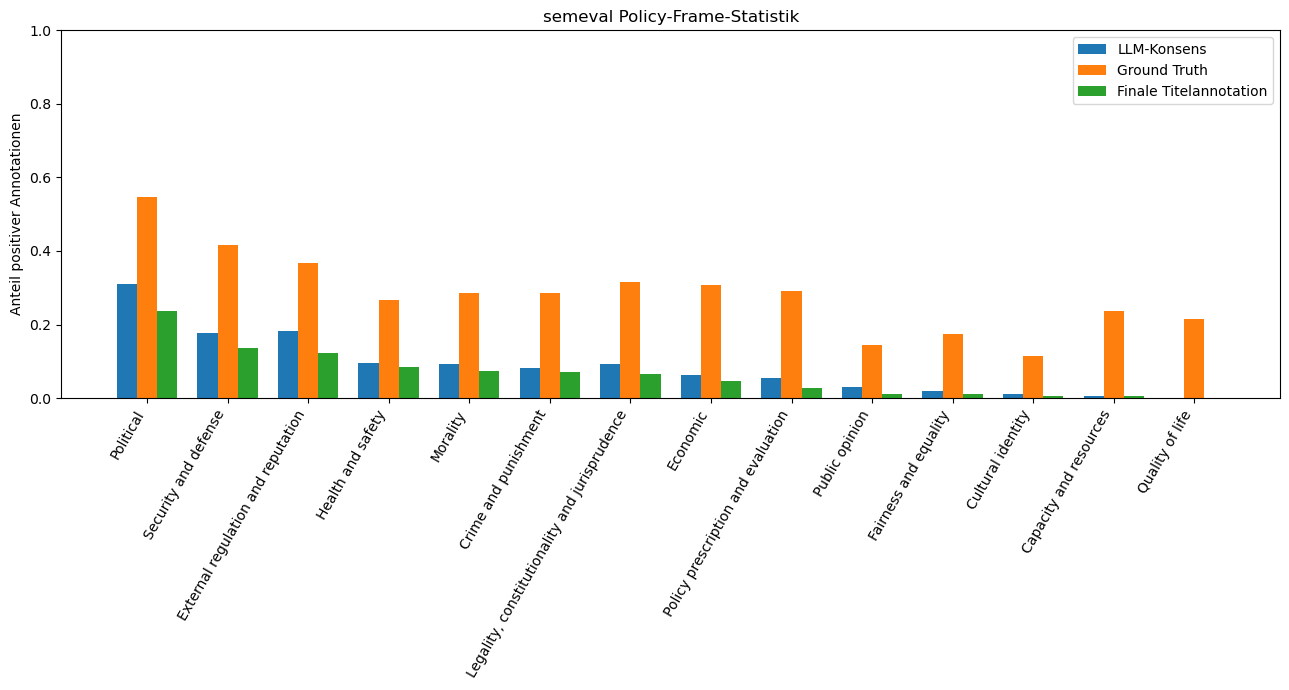

In [ ]:
statistics_rows = []

for frame in FRAME_COLUMNS:
    row = {"Frame": frame}

    for model_name, df in zip(llm_names, llm_indexed):
        row[f"{model_name} positive"] = int(df[frame].sum())
        row[f"{model_name} Anteil"] = float(df[frame].mean())

    row["LLM-Konsens positive"] = int(consensus_binary[frame].sum())
    row["LLM-Konsens Anteil"] = float(consensus_binary[frame].mean())

    row["Ground Truth positive"] = int(gt_indexed[frame].sum())
    row["Ground Truth Anteil"] = float(gt_indexed[frame].mean())

    row["Finale Titelannotation positive"] = int(final_binary[frame].sum())
    row["Finale Titelannotation Anteil"] = float(final_binary[frame].mean())

    statistics_rows.append(row)

frame_statistics = pd.DataFrame(statistics_rows)
#display(frame_statistics)

plot_df = frame_statistics[
    ["Frame", "LLM-Konsens Anteil", "Ground Truth Anteil", "Finale Titelannotation Anteil"]
].sort_values("Finale Titelannotation Anteil", ascending=False)

plt.figure(figsize=(13, 7))
x = np.arange(len(plot_df))
width = 0.25
plt.bar(x - width, plot_df["LLM-Konsens Anteil"], width, label="LLM-Konsens")
plt.bar(x, plot_df["Ground Truth Anteil"], width, label="Ground Truth")
plt.bar(x + width, plot_df["Finale Titelannotation Anteil"], width, label="Finale Titelannotation")
plt.xticks(x, plot_df["Frame"], rotation=60, ha="right")
plt.ylabel("Anteil positiver Annotationen")
plt.title("semeval Policy-Frame-Statistik")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FILES["plot"], dpi=200, bbox_inches="tight")
plt.show()


Centralised Analysis and Quality Report

In [ ]:
agreement_counts = consensus_protocol["Übereinstimmung"].value_counts().to_dict()

summary_lines = [
    "semeval Policy-Frame-Titelannotation – zentrale Auswertung",
    "=" * 60,
    "",
    f"Artikel: {len(article_ids)}",
    f"LLM-Modelle: {LLM_COUNT}",
    "Konsensregel: mindestens 2 von 3 positiven Stimmen",
    "LLM-Umcodierung: 2 -> 1",
    "Ground Truth: ground_truth_full.csv",
    "",
    f"Konsensuelle positive Artikel-Frame-Paare: {consensus_pairs}",
    f"Davon 2/3: {agreement_counts.get('2/3', 0)}",
    f"Davon 3/3: {agreement_counts.get('3/3', 0)}",
    f"Nach Ground-Truth-Abgleich behalten: {kept_pairs}",
    f"Nach Ground-Truth-Abgleich gestrichen: {removed_pairs}",
    f"Metadatenabweichungen zwischen Dateien: {len(metadata_mismatches)}",
    "",
    "Finale positive Frames nach Frame:",
]

for frame in FRAME_COLUMNS:
    summary_lines.append(
        f"  - {frame}: {int(final_binary[frame].sum())}"
    )

summary_text = "\n".join(summary_lines) + "\n"
OUTPUT_FILES["summary"].write_text(summary_text, encoding="utf-8")
print(summary_text)


semeval Policy-Frame-Titelannotation – zentrale Auswertung

Artikel: 1401
LLM-Modelle: 3
Konsensregel: mindestens 2 von 3 positiven Stimmen
LLM-Umcodierung: 2 -> 1
Ground Truth: ground_truth_full.csv

Konsensuelle positive Artikel-Frame-Paare: 1704
Davon 2/3: 935
Davon 3/3: 769
Nach Ground-Truth-Abgleich behalten: 1258
Nach Ground-Truth-Abgleich gestrichen: 446
Metadatenabweichungen zwischen Dateien: 0

Finale positive Frames nach Frame:
  - Economic: 65
  - Capacity and resources: 6
  - Morality: 103
  - Fairness and equality: 15
  - Legality, constitutionality and jurisprudence: 91
  - Policy prescription and evaluation: 40
  - Crime and punishment: 99
  - Security and defense: 191
  - Health and safety: 119
  - Quality of life: 1
  - Cultural identity: 8
  - Public opinion: 17
  - Political: 333
  - External regulation and reputation: 170



saving data

In [ ]:
# 01 – LLM-Konsens (breites Format)
consensus_wide.to_excel(OUTPUT_FILES["consensus"], index=False)

# 02 – vollständiges Konsensprotokoll
with pd.ExcelWriter(OUTPUT_FILES["protocol"], engine="openpyxl") as writer:
    consensus_protocol.to_excel(writer, sheet_name="Konsensprotokoll", index=False)
    agreement_summary.to_excel(writer, sheet_name="Übereinstimmung", index=False)
    id_report.to_excel(writer, sheet_name="ID_Prüfung", index=False)
    if not metadata_mismatches.empty:
        metadata_mismatches.to_excel(
            writer, sheet_name="Metadatenabweichungen", index=False
        )

# 03 – finale Titelannotation
final_title_annotations.to_excel(OUTPUT_FILES["final"], index=False)

# 04 – Streichungsprotokoll
with pd.ExcelWriter(OUTPUT_FILES["removal"], engine="openpyxl") as writer:
    removal_protocol.to_excel(
        writer, sheet_name="Streichungsprotokoll", index=False
    )
    removed_summary = (
        removal_protocol[removal_protocol["Behalten"] == 0]
        .groupby("Frame", as_index=False)
        .size()
        .rename(columns={"size": "Gestrichene_Paare"})
    )
    removed_summary.to_excel(writer, sheet_name="Nach_Frame", index=False)

# 05 – Frame-Statistik
frame_statistics.to_excel(OUTPUT_FILES["statistics"], index=False)

print("\nErzeugte Dateien:")
for path in OUTPUT_FILES.values():
    if path.exists():
        print(f" - {path.name} ({path.stat().st_size:,} Bytes)")

display(Markdown(f"**Ausgabeordner:** `{OUTPUT_DIR.resolve()}`"))



Erzeugte Dateien:
 - semeval_01_llm_konsens.xlsx (130,120 Bytes)
 - semeval_02_konsensprotokoll.xlsx (1,740,544 Bytes)
 - semeval_03_finale_titelannotationen.xlsx (129,392 Bytes)
 - semeval_04_streichungsprotokoll.xlsx (155,274 Bytes)
 - semeval_05_frame_statistik.xlsx (7,290 Bytes)
 - semeval_05_frame_statistik.png (237,366 Bytes)
 - semeval_06_zentrale_auswertung.txt (917 Bytes)


**Ausgabeordner:** `/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP_fork_abgabe01/a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.5_konsens_bildung/semeval_2023/ordner_fuer_aktualisiertes_notebook/semeval_konsens_output`

In [ ]:
assert len(consensus_wide) == len(article_ids)
assert len(final_title_annotations) == len(article_ids)
assert set(final_title_annotations[ID_COLUMN]) == set(article_ids)
assert all(frame in final_title_annotations.columns for frame in FRAME_COLUMNS)
assert set(final_title_annotations[FRAME_COLUMNS].to_numpy().ravel()).issubset({0, 1})
assert all(path.exists() for path in OUTPUT_FILES.values())

print(f"✓ {len(article_ids):,} Artikel vorhanden")
print("✓ Filename-IDs in allen vier Dateien identisch und eindeutig")
print(f"✓ {len(FRAME_COLUMNS)} Frame-Spalten vorhanden")
print("✓ Finale Frame-Werte ausschließlich 0/1")
print("✓ Alle vereinbarten Ausgabedateien vorhanden")
print("\nWorkflow erfolgreich abgeschlossen.")


✓ 1,401 Artikel vorhanden
✓ Filename-IDs in allen vier Dateien identisch und eindeutig
✓ 14 Frame-Spalten vorhanden
✓ Finale Frame-Werte ausschließlich 0/1
✓ Alle vereinbarten Ausgabedateien vorhanden

Workflow erfolgreich abgeschlossen.


final title annotation: semeval_03_finale_titelannotationen.xlsx

#2. Additional Data
Chinese SemEval, stratified sample MFC

see folder "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc"

##external extension of Semeval 2023 task 3 - subtask 2 (abbreviated as "chn")



### raw data

Chinese News Framing

Github repository: https://github.com/GateNLP/chinese-news-framing

Zenodo DOI: https://doi.org/10.5281/zenodo.14659362

Downoad of the chinese_news_framing_dataset.csv from Zenodo resulting in raw data (weblink, train/test/dev split, multiple annotations.

The following section processes chinese_news_framing_dataset.csv into an adequate format.

in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.1_datasets_raw/raw-data/chinese_news_framing_dataset_download_zenodo.csv"

###formating chinese_news_framing_dataset_download_zenodo.csv

resulting in a new file: ground_truth_chinese_extension_semeval.xlsx

saved in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.1_datasets_raw/bearbeitet/chinese_dataset"

In [ ]:
import csv
import openpyxl

# 1. Pfade definieren
csv_file = 'chinese_news_framing_dataset.csv'
gt_template_file = 'ground_truth_full.xlsx'
output_file = 'ground_truth_chinese_extension_semeval.xlsx'

# 2. Excel-Header via openpyxl auslesen (ohne Pandas/NumPy C-Engine)
gt_wb = openpyxl.load_workbook(gt_template_file, read_only=True)
gt_sheet = gt_wb.active
target_columns = [cell.value for cell in next(gt_sheet.iter_rows(max_row=1))]
gt_wb.close()

# 3. Framing-Mapping definieren
tag_mapping = {
    'Economic': 'Economic',
    'Capacity_and_resources': 'Capacity and resources',
    'Morality': 'Morality',
    'Fairness_and_equality': 'Fairness and equality',
    'Legality_Constitutionality_and_jurisprudence': 'Legality, constitutionality and jurisprudence',
    'Policy_prescription_and_evaluation': 'Policy prescription and evaluation',
    'Crime_and_punishment': 'Crime and punishment',
    'Security_and_defense': 'Security and defense',
    'Health_and_safety': 'Health and safety',
    'Quality_of_life': 'Quality of life',
    'Cultural_identity': 'Cultural identity',
    'Public_opinion': 'Public opinion',
    'Political': 'Political',
    'External_regulation_and_reputation': 'External regulation and reputation'
}

# 4. CSV verarbeiten
records = []
with open(csv_file, mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Standardmäßig alle Felder mit 0 initialisieren
        entry = {col: 0 for col in target_columns}
        entry['Filename'] = str(row['web_link'])
        entry['Language'] = 'chinese'

        frames_val = row.get('frames', '')
        if frames_val:
            active_tags = [tag.strip() for tag in str(frames_val).split(',')]
            for tag in active_tags:
                if tag in tag_mapping:
                    entry[tag_mapping[tag]] = 1

        records.append(entry)

# 5. Neue Excel-Datei direkt mit openpyxl schreiben
wb_out = openpyxl.Workbook()
ws_out = wb_out.active
ws_out.title = "Sheet1"

# Kopfzeile schreiben
ws_out.append(target_columns)

# Datenzeilen schreiben
for rec in records:
    row_values = [rec[col] for col in target_columns]
    ws_out.append(row_values)

wb_out.save(output_file)

print(f"Erfolgreich konvertiert! {len(records)} Zeilen wurden in '{output_file}' gespeichert.")

###Extensive webcrawler: adds the titles corresponding to the weblinks

note: not all titles were succesfully retrieved. Some titles were added manually. However some rows still show an error ("err"). These need to be deleted.

In [ ]:
import os
import re
import time
import random
import unicodedata
from urllib.parse import urlparse, urlunparse

import openpyxl
import requests
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


# ============================================================
# KONFIGURATION
# ============================================================

INPUT_FILE = (
    "/Users/Familie/Documents/Uni_Regensburg/"
    "A_Digital_Humanities/2SE_SS26/"
    "Natural_Language_Engineering/projekt/"
    "frame_detect_NLP/Y_test_additional_dataset/datasets/"
    "bearbeitet/chinese_dataset/"
    "ground_truth_chinese_extension_semeval.xlsx"
)

OUTPUT_FILE = (
    "/Users/Familie/Documents/Uni_Regensburg/"
    "A_Digital_Humanities/2SE_SS26/"
    "Natural_Language_Engineering/projekt/"
    "frame_detect_NLP/Y_test_additional_dataset/datasets/"
    "bearbeitet/chinese_dataset/"
    "ground_truth_chinese_extension_semeval_with_titles.xlsx"
)

LOG_FILE = (
    "/Users/Familie/Documents/Uni_Regensburg/"
    "A_Digital_Humanities/2SE_SS26/"
    "Natural_Language_Engineering/projekt/"
    "frame_detect_NLP/Y_test_additional_dataset/datasets/"
    "bearbeitet/chinese_dataset/"
    "headline_crawl_log.txt"
)

URL_COLUMN = "Filename"
TITLE_COLUMN = "Headline_GER"

# Zwischen Requests warten.
MIN_DELAY = 0.8
MAX_DELAY = 1.8

REQUEST_TIMEOUT = 20

# Wenn True:
# Bereits vorhandene Headline_GER-Werte werden nicht erneut gecrawlt.
SKIP_EXISTING = True

# Wenn True:
# Nach einem fehlgeschlagenen Crawl wird "err" geschrieben.
WRITE_ERR = True


# ============================================================
# USER-AGENT
# ============================================================

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/139.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,application/xml;"
        "q=0.9,image/avif,image/webp,*/*;q=0.8"
    ),
    "Accept-Language": (
        "zh-CN,zh;q=0.9,en-US;q=0.7,en;q=0.6"
    ),
    "Connection": "keep-alive",
}


# ============================================================
# DOMAINEN
# ============================================================

NTDTV = {
    "www.ntdtv.com",
}

EPOCH_TIMES = {
    "www.epochtimes.com",
}

RFI = {
    "www.rfi.fr",
}

VOA = {
    "www.voachinese.com",
}

REUTERS = {
    "cn.reuters.com",
}

THE_PAPER = {
    "www.thepaper.cn",
}

XINHUA = {
    "www.news.cn",
    "hlj.news.cn",
    "bj.news.cn",
}

DW = {
    "www.dw.com",
}

CHINA_DAILY = {
    "cn.chinadaily.com.cn",
    "china.chinadaily.com.cn",
    "finance.chinadaily.com.cn",
    "chuangxin.chinadaily.com.cn",
    "caijing.chinadaily.com.cn",
    "hlj.chinadaily.com.cn",
}

NYT = {
    "cn.nytimes.com",
}

FT = {
    "cn.ft.com",
}

BBC = {
    "www.bbc.com",
}

CHINA_DIGITAL_TIMES = {
    "chinadigitaltimes.net",
}

RFA = {
    "www.rfa.org",
}

SPECIAL_OTHER = {
    "www.gsftyg.com",
}


# ============================================================
# SESSION MIT RETRIES
# ============================================================

def create_session():
    session = requests.Session()

    retry_strategy = Retry(
        total=3,
        connect=3,
        read=3,
        status=3,
        backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False,
    )

    adapter = HTTPAdapter(
        max_retries=retry_strategy,
        pool_connections=10,
        pool_maxsize=10,
    )

    session.mount("http://", adapter)
    session.mount("https://", adapter)

    session.headers.update(HEADERS)

    return session


# ============================================================
# URL NORMALISIERUNG
# ============================================================

def normalize_url(url):
    """
    Normalisiert problematische URLs.

    Insbesondere:
    http://www.rfi.fr//cn/...
        ->
    https://www.rfi.fr/cn/...
    """

    if not isinstance(url, str):
        return None

    url = url.strip()

    if not url:
        return None

    if not re.match(r"^https?://", url, re.IGNORECASE):
        return None

    parsed = urlparse(url)

    scheme = parsed.scheme.lower()
    hostname = parsed.netloc.lower()

    # RFI:
    # Doppelten Slash im Pfad entfernen.
    path = re.sub(r"/{2,}", "/", parsed.path)

    # Bei RFI HTTPS bevorzugen.
    if hostname == "www.rfi.fr":
        scheme = "https"

    normalized = urlunparse(
        (
            scheme,
            hostname,
            path,
            parsed.params,
            parsed.query,
            parsed.fragment,
        )
    )

    return normalized


# ============================================================
# TEXT-BEREINIGUNG
# ============================================================

def clean_title(text):
    """
    Bereinigt einen extrahierten Titel.
    """

    if text is None:
        return None

    text = str(text)

    # Unicode normalisieren
    text = unicodedata.normalize("NFKC", text)

    # Whitespace vereinheitlichen
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    if not text:
        return None

    # Häufige Trennzeichen am Anfang/Ende entfernen
    text = text.strip(" |-_—–·•")

    if not text:
        return None

    return text


# ============================================================
# CHINESISCH-ERKENNUNG
# ============================================================

def count_chinese_characters(text):
    if not text:
        return 0

    count = 0

    for char in text:
        code = ord(char)

        if (
            0x3400 <= code <= 0x4DBF
            or 0x4E00 <= code <= 0x9FFF
            or 0xF900 <= code <= 0xFAFF
        ):
            count += 1

    return count


def contains_chinese(text):
    return count_chinese_characters(text) >= 2


# ============================================================
# OFFENSICHTLICH UNGEEIGNETE TITEL
# ============================================================

GENERIC_BAD_TITLES = {
    "首页",
    "首頁",
    "新闻",
    "新聞",
    "国际",
    "國際",
    "中国",
    "中國",
    "财经",
    "財經",
    "视频",
    "視頻",
    "图片",
    "圖片",
    "搜索",
    "搜尋",
    "登录",
    "登入",
    "注册",
    "註冊",
    "404",
    "page not found",
    "error",
}


def looks_like_navigation_or_site_name(title):
    if not title:
        return True

    normalized = title.lower().strip()

    if normalized in {
        x.lower() for x in GENERIC_BAD_TITLES
    }:
        return True

    # Typische Fehlerseiten
    error_patterns = [
        "404",
        "page not found",
        "access denied",
        "forbidden",
        "error",
        "robot check",
        "captcha",
    ]

    if any(pattern in normalized for pattern in error_patterns):
        return True

    return False


# ============================================================
# TITEL-PLAUSIBILITÄT
# ============================================================

def title_is_plausible(title, source_domain=None):
    """
    Konservative Prüfung.

    Wir wollen lieber "err" als einen falschen Titel.
    """

    title = clean_title(title)

    if not title:
        return False

    if looks_like_navigation_or_site_name(title):
        return False

    chinese_count = count_chinese_characters(title)

    # Da wir chinesische Originaltitel erwarten,
    # muss der Titel mindestens zwei chinesische Zeichen enthalten.
    if chinese_count < 2:
        return False

    # Extrem lange Inhalte sind wahrscheinlich kein Titel,
    # sondern Volltext / Beschreibung.
    if len(title) > 300:
        return False

    # Ein einzelnes sehr langes Segment ohne Satzzeichen
    # ist ebenfalls verdächtig.
    if len(title) > 220 and chinese_count < 20:
        return False

    # Meta-/UI-Fragmente
    bad_fragments = [
        "cookie",
        "javascript",
        "subscribe",
        "newsletter",
        "copyright",
        "privacy policy",
        "隐私政策",
        "隐私權",
        "登录",
        "登入",
        "注册",
        "註冊",
    ]

    lower_title = title.lower()

    for fragment in bad_fragments:
        if fragment.lower() in lower_title:
            return False

    return True


# ============================================================
# DUPLIKATE AUS TITEL-KANDIDATEN ENTFERNEN
# ============================================================

def unique_candidates(candidates):
    result = []
    seen = set()

    for candidate in candidates:
        candidate = clean_title(candidate)

        if not candidate:
            continue

        key = candidate.casefold()

        if key in seen:
            continue

        seen.add(key)
        result.append(candidate)

    return result


# ============================================================
# META-TITEL
# ============================================================

def extract_meta_candidates(soup):
    candidates = []

    # OpenGraph
    for tag in soup.find_all("meta"):
        prop = tag.get("property", "")
        name = tag.get("name", "")
        content = tag.get("content")

        if not content:
            continue

        prop = prop.lower().strip()
        name = name.lower().strip()

        if prop in {
            "og:title",
            "twitter:title",
        }:
            candidates.append(content)

        if name in {
            "title",
            "headline",
        }:
            candidates.append(content)

    return candidates


# ============================================================
# JSON-LD
# ============================================================

def extract_jsonld_candidates(soup):
    candidates = []

    scripts = soup.find_all(
        "script",
        type=re.compile(
            r"application/ld\+json",
            re.IGNORECASE,
        ),
    )

    import json

    def process_object(obj):
        if isinstance(obj, dict):

            # Häufige Schema.org-Felder
            for key in [
                "headline",
                "name",
                "alternativeHeadline",
            ]:
                value = obj.get(key)

                if isinstance(value, str):
                    candidates.append(value)

            graph = obj.get("@graph")

            if isinstance(graph, list):
                for item in graph:
                    process_object(item)

        elif isinstance(obj, list):
            for item in obj:
                process_object(item)

    for script in scripts:

        raw = script.string or script.get_text()

        if not raw:
            continue

        raw = raw.strip()

        try:
            data = json.loads(raw)
            process_object(data)

        except Exception:
            continue

    return candidates


# ============================================================
# ALLGEMEINE HTML-KANDIDATEN
# ============================================================

def extract_generic_candidates(soup):
    candidates = []

    # h1 ist meist die wichtigste Quelle.
    for h1 in soup.find_all("h1"):
        text = h1.get_text(" ", strip=True)

        if text:
            candidates.append(text)

    # h2 nur als schwächerer Fallback.
    for h2 in soup.find_all("h2"):
        text = h2.get_text(" ", strip=True)

        if text:
            candidates.append(text)

    return candidates


# ============================================================
# DOMAIN-SPEZIFISCHE EXTRAKTOREN
# ============================================================

def extract_ntdtv(soup):
    candidates = []

    # NTDTV
    selectors = [
        "h1",
        "article h1",
        "[class*='article'] h1",
        "[class*='news'] h1",
        "[class*='title'] h1",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_voa(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[class*='headline'] h1",
        "[class*='title'] h1",
        "[data-testid*='headline']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_rfi(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[class*='title'] h1",
        "[class*='headline'] h1",
        "[class*='article'] h1",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_thepaper(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        ".news_txt h1",
        ".newsdetail h1",
        "[class*='news'] h1",
        "[class*='title'] h1",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_xinhua(soup):
    candidates = []

    selectors = [
        "h1",
        ".title",
        ".main-title",
        ".article-title",
        "article h1",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            text = element.get_text(" ", strip=True)

            if text:
                candidates.append(text)

    return candidates


def extract_chinadaily(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        ".article-title",
        ".title",
        "[class*='article'] h1",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_epochtimes(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        ".article-title",
        ".title",
        "[class*='article'] h1",
        "[class*='title'] h1",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_dw(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[class*='headline']",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_nyt(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[data-testid='headline']",
        "[class*='headline']",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_ft(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[class*='headline']",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_bbc(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[data-testid='headline']",
        "[class*='headline']",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_cdt(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        ".entry-title",
        ".post-title",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


def extract_rfa(soup):
    candidates = []

    selectors = [
        "h1",
        "article h1",
        "[class*='headline']",
        "[class*='title']",
    ]

    for selector in selectors:
        for element in soup.select(selector):
            candidates.append(
                element.get_text(" ", strip=True)
            )

    return candidates


# ============================================================
# DOMAIN-EXTRAKTOR AUSWÄHLEN
# ============================================================

def get_domain_specific_candidates(soup, hostname):
    if hostname in NTDTV:
        return extract_ntdtv(soup)

    if hostname in EPOCH_TIMES:
        return extract_epochtimes(soup)

    if hostname in RFI:
        return extract_rfi(soup)

    if hostname in VOA:
        return extract_voa(soup)

    if hostname in THE_PAPER:
        return extract_thepaper(soup)

    if hostname in XINHUA:
        return extract_xinhua(soup)

    if hostname in CHINA_DAILY:
        return extract_chinadaily(soup)

    if hostname in DW:
        return extract_dw(soup)

    if hostname in NYT:
        return extract_nyt(soup)

    if hostname in FT:
        return extract_ft(soup)

    if hostname in BBC:
        return extract_bbc(soup)

    if hostname in CHINA_DIGITAL_TIMES:
        return extract_cdt(soup)

    if hostname in RFA:
        return extract_rfa(soup)

    if hostname in REUTERS:
        # Reuters ist bei den alten URLs problematisch.
        # Nicht aus URL-Slug rekonstruieren.
        return []

    return []


# ============================================================
# TITEL AUS EINER SEITE EXTRAHIEREN
# ============================================================

def extract_title_from_html(html, hostname):
    soup = BeautifulSoup(html, "html.parser")

    # --------------------------------------------------------
    # 1. Domain-spezifische Kandidaten
    # --------------------------------------------------------

    domain_candidates = get_domain_specific_candidates(
        soup,
        hostname,
    )

    # --------------------------------------------------------
    # 2. JSON-LD
    # --------------------------------------------------------

    jsonld_candidates = extract_jsonld_candidates(soup)

    # --------------------------------------------------------
    # 3. OpenGraph / Meta
    # --------------------------------------------------------

    meta_candidates = extract_meta_candidates(soup)

    # --------------------------------------------------------
    # 4. Generische HTML-Kandidaten
    # --------------------------------------------------------

    generic_candidates = extract_generic_candidates(soup)

    # --------------------------------------------------------
    # Kandidaten in Prioritätsreihenfolge
    # --------------------------------------------------------

    all_candidates = []

    all_candidates.extend(domain_candidates)
    all_candidates.extend(jsonld_candidates)
    all_candidates.extend(meta_candidates)
    all_candidates.extend(generic_candidates)

    all_candidates = unique_candidates(
        all_candidates
    )

    # --------------------------------------------------------
    # Plausibilitätsprüfung
    # --------------------------------------------------------

    for candidate in all_candidates:

        candidate = clean_title(candidate)

        if title_is_plausible(
            candidate,
            hostname,
        ):
            return candidate

    return None


# ============================================================
# HTTP RESPONSE VALIDIEREN
# ============================================================

def response_looks_like_html(response):
    content_type = response.headers.get(
        "Content-Type",
        "",
    ).lower()

    if "text/html" in content_type:
        return True

    if "application/xhtml+xml" in content_type:
        return True

    # Manche ältere Webseiten setzen keinen sauberen
    # Content-Type.
    beginning = response.content[:500].lower()

    if b"<html" in beginning:
        return True

    if b"<!doctype html" in beginning:
        return True

    return False


# ============================================================
# EINZELNE URL SCRAPEN
# ============================================================

def scrape_title(url, session):
    normalized_url = normalize_url(url)

    if not normalized_url:
        return None, "invalid_url"

    parsed = urlparse(normalized_url)
    hostname = parsed.netloc.lower()

    try:
        time.sleep(
            random.uniform(
                MIN_DELAY,
                MAX_DELAY,
            )
        )

        response = session.get(
            normalized_url,
            timeout=REQUEST_TIMEOUT,
            allow_redirects=True,
        )

        status = response.status_code

        if status >= 400:
            return None, f"http_{status}"

        if not response_looks_like_html(response):
            return None, "not_html"

        # Encoding verbessern.
        if not response.encoding:
            response.encoding = response.apparent_encoding

        # Bei problematischen chinesischen Seiten:
        if response.encoding.lower() in {
            "iso-8859-1",
            "ascii",
        }:
            response.encoding = response.apparent_encoding

        title = extract_title_from_html(
            response.text,
            hostname,
        )

        if title:
            return title, "success"

        return None, "title_not_found"

    except requests.exceptions.Timeout:
        return None, "timeout"

    except requests.exceptions.TooManyRedirects:
        return None, "too_many_redirects"

    except requests.exceptions.ConnectionError:
        return None, "connection_error"

    except requests.exceptions.RequestException as exc:
        return None, (
            "request_error:"
            + exc.__class__.__name__
        )

    except Exception as exc:
        return None, (
            "unexpected_error:"
            + exc.__class__.__name__
        )


# ============================================================
# WORKBOOK LADEN
# ============================================================

def load_workbook_safely(file_path):
    """
    Absichtlich nur openpyxl.

    Dadurch umgehen wir den ursprünglichen Fehler:

        TypeError:
        Cannot convert numpy.ndarray to numpy.ndarray

    Es gibt hier keinen Pandas-/NumPy-Zwischenschritt.
    """

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Datei nicht gefunden:\n{file_path}"
        )

    workbook = openpyxl.load_workbook(
        file_path,
        data_only=False,
    )

    return workbook


# ============================================================
# HEADER FINDEN
# ============================================================

def find_header_column(worksheet, header_name):
    for cell in worksheet[1]:

        if cell.value == header_name:
            return cell.column

    return None


# ============================================================
# NEUE SPALTE ANLEGEN
# ============================================================

def ensure_title_column(worksheet):
    column = find_header_column(
        worksheet,
        TITLE_COLUMN,
    )

    if column is not None:
        return column

    new_column = worksheet.max_column + 1

    cell = worksheet.cell(
        row=1,
        column=new_column,
    )

    cell.value = TITLE_COLUMN

    return new_column


# ============================================================
# CRAWL-LOG
# ============================================================

def write_log(log_file, message):
    with open(
        log_file,
        "a",
        encoding="utf-8",
    ) as f:
        f.write(message + "\n")


# ============================================================
# HAUPTPROGRAMM
# ============================================================

def main():

    print("=" * 70)
    print("CHINESISCHE HEADLINES CRAWLER")
    print("=" * 70)

    print(f"\nEingabe:")
    print(INPUT_FILE)

    print(f"\nAusgabe:")
    print(OUTPUT_FILE)

    print(f"\nLog:")
    print(LOG_FILE)

    # --------------------------------------------------------
    # Workbook laden
    # --------------------------------------------------------

    workbook = load_workbook_safely(
        INPUT_FILE
    )

    worksheet = workbook.active

    print(
        f"\nArbeitsblatt: {worksheet.title}"
    )

    print(
        f"Zeilen: {worksheet.max_row - 1}"
    )

    print(
        f"Spalten vorher: {worksheet.max_column}"
    )

    # --------------------------------------------------------
    # URL-Spalte suchen
    # --------------------------------------------------------

    url_column = find_header_column(
        worksheet,
        URL_COLUMN,
    )

    if url_column is None:
        raise ValueError(
            f"Die Spalte '{URL_COLUMN}' "
            f"wurde nicht gefunden."
        )

    # --------------------------------------------------------
    # Headline-Spalte anlegen
    # --------------------------------------------------------

    title_column = ensure_title_column(
        worksheet
    )

    print(
        f"'{TITLE_COLUMN}' befindet sich jetzt "
        f"in Spalte {title_column}."
    )

    print(
        f"Spalten nachher: "
        f"{worksheet.max_column}"
    )

    # --------------------------------------------------------
    # Session
    # --------------------------------------------------------

    session = create_session()

    # --------------------------------------------------------
    # Statistik
    # --------------------------------------------------------

    total = worksheet.max_row - 1

    success_count = 0
    error_count = 0
    skipped_count = 0

    status_counter = {}

    # Log-Datei neu beginnen.
    with open(
        LOG_FILE,
        "w",
        encoding="utf-8",
    ) as f:

        f.write(
            "HEADLINE CRAWL LOG\n"
        )

        f.write(
            "=" * 70 + "\n"
        )

        f.write(
            f"Input: {INPUT_FILE}\n"
        )

        f.write(
            f"Output: {OUTPUT_FILE}\n"
        )

        f.write(
            "=" * 70 + "\n\n"
        )

    # --------------------------------------------------------
    # Zeilen durchlaufen
    # --------------------------------------------------------

    for row_number in range(
        2,
        worksheet.max_row + 1,
    ):

        url = worksheet.cell(
            row=row_number,
            column=url_column,
        ).value

        title_cell = worksheet.cell(
            row=row_number,
            column=title_column,
        )

        # ----------------------------------------------------
        # Bereits vorhandenen Titel behalten
        # ----------------------------------------------------

        if SKIP_EXISTING:

            existing = title_cell.value

            if (
                existing is not None
                and str(existing).strip() != ""
            ):

                skipped_count += 1

                print(
                    f"[{row_number - 1}/{total}] "
                    f"SKIP: bereits vorhanden"
                )

                continue

        # ----------------------------------------------------
        # URL prüfen
        # ----------------------------------------------------

        if not isinstance(url, str):
            title_cell.value = "err"

            error_count += 1

            status_counter[
                "invalid_url"
            ] = (
                status_counter.get(
                    "invalid_url",
                    0,
                ) + 1
            )

            write_log(
                LOG_FILE,
                (
                    f"{row_number}\t"
                    f"invalid_url\t"
                    f"{url}"
                ),
            )

            continue

        # ----------------------------------------------------
        # Crawl
        # ----------------------------------------------------

        title, status = scrape_title(
            url,
            session,
        )

        status_counter[status] = (
            status_counter.get(
                status,
                0,
            ) + 1
        )

        # ----------------------------------------------------
        # Erfolg
        # ----------------------------------------------------

        if title:

            title_cell.value = title

            success_count += 1

            print(
                f"[{row_number - 1}/{total}] "
                f"OK: {title}"
            )

            write_log(
                LOG_FILE,
                (
                    f"{row_number}\t"
                    f"success\t"
                    f"{url}\t"
                    f"{title}"
                ),
            )

        # ----------------------------------------------------
        # Fehler
        # ----------------------------------------------------

        else:

            if WRITE_ERR:
                title_cell.value = "err"

            error_count += 1

            print(
                f"[{row_number - 1}/{total}] "
                f"ERR: {status}\n"
                f"    {url}"
            )

            write_log(
                LOG_FILE,
                (
                    f"{row_number}\t"
                    f"{status}\t"
                    f"{url}"
                ),
            )

        # ----------------------------------------------------
        # Zwischenspeichern
        # ----------------------------------------------------

        # Alle 25 Datensätze speichern.
        if (
            (row_number - 1) % 25 == 0
        ):

            workbook.save(
                OUTPUT_FILE
            )

            print(
                "  -> Zwischenstand gespeichert."
            )

    # --------------------------------------------------------
    # Finale Speicherung
    # --------------------------------------------------------

    workbook.save(
        OUTPUT_FILE
    )

    # --------------------------------------------------------
    # Session schließen
    # --------------------------------------------------------

    session.close()

    # --------------------------------------------------------
    # Zusammenfassung
    # --------------------------------------------------------

    print("\n")
    print("=" * 70)
    print("CRAWLER ABGESCHLOSSEN")
    print("=" * 70)

    print(
        f"Datensätze insgesamt:     {total}"
    )

    print(
        f"Erfolgreich extrahiert:   {success_count}"
    )

    print(
        f"Fehler / 'err':           {error_count}"
    )

    print(
        f"Bereits vorhanden:        {skipped_count}"
    )

    print("\nStatus-Verteilung:")

    for status, count in sorted(
        status_counter.items(),
        key=lambda x: (-x[1], x[0]),
    ):

        print(
            f"  {status:<30} {count}"
        )

    print("\n")
    print(
        f"Excel gespeichert unter:\n"
        f"{OUTPUT_FILE}"
    )

    print(
        f"\nLog gespeichert unter:\n"
        f"{LOG_FILE}"
    )

    print("=" * 70)


# ============================================================
# START
# ============================================================

if __name__ == "__main__":
    main()

CHINESISCHE HEADLINES CRAWLER

Eingabe:
/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_test_additional_dataset/datasets/bearbeitet/chinese_dataset/ground_truth_chinese_extension_semeval.xlsx

Ausgabe:
/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_test_additional_dataset/datasets/bearbeitet/chinese_dataset/ground_truth_chinese_extension_semeval_with_titles.xlsx

Log:
/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_test_additional_dataset/datasets/bearbeitet/chinese_dataset/headline_crawl_log.txt

Arbeitsblatt: Sheet1
Zeilen: 353
Spalten vorher: 16
'Headline_GER' befindet sich jetzt in Spalte 17.
Spalten nachher: 17
[1/353] OK: AI可能成为灾难 马斯克吁暂停研发加强监管
[2/353] OK: 重庆一高速隧道多车追尾 燃起熊熊大火(视频)
[3/353] OK: 美国药管机构批准紧急使用莫德纳新冠疫苗
[4/353] ERR: http_403
    http://www.rfi

### manual adjustment

The webscraper was not able to fully add all titles. Some articles were added manually. However some articles were no longer available and therefore removed.

Resulting in the file: "c_manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx"

###chn translation

In [ ]:
!pip install openpyxl deep-translator tqdm

import os
import time
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm
from google.colab import files

# ============================================================
# CONFIG
# ============================================================

INPUT_FILES = [
    'manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx',
    'mfc_stratified_sample_converted.xlsx' #only the chn dataset was translated with this code,
    #the mfc dataset was tranlated via deepl
]

# ============================================================
# PREPARE TRANSLATOR & HELPER FUNCTION
# ============================================================

translator = GoogleTranslator(source='auto', target='de')

def safe_translate(text, translator_instance, max_retries=4, base_delay=1.5):
    """
    Übersetzt Text, erkennt Server-Fehler-Strings im Ergebnis
    und erzwingt bei Blockaden längere Pausen.
    """
    if pd.isna(text):
        return text

    text_str = str(text).strip()
    if text_str.lower() in ['err', '']:
        return text

    for attempt in range(max_retries):
        try:
            translated = translator_instance.translate(text_str)

            # Prüfen, ob Google Translate die Fehlerseite als Text zurückgeliefert hat
            if translated and ("Error 500" in str(translated) or "That’s an error" in str(translated)):
                raise ValueError("Google Translate Server-Fehler erhalten")

            # Kurze Pause nach jedem erfolgreichen Aufruf
            time.sleep(0.8)
            return translated

        except Exception:
            # Bei Fehler exponentiell länger warten (z.B. 2s, 4s, 8s, 16s)
            wait_time = base_delay * (2 ** attempt)
            if attempt < max_retries - 1:
                time.sleep(wait_time)
            else:
                # Falls alle Versuche fehlschlagen, Originaltext behalten
                print(f"\n[Zeile übersprungen nach {max_retries} Versuchen]: '{text_str[:30]}...'")
                return text_str

# ============================================================
# TRANSLATE EXCEL FILES
# ============================================================

for input_path in INPUT_FILES:

    if not os.path.isfile(input_path):
        print(f"Datei nicht gefunden: {input_path}")
        continue

    print(f"\nVerarbeite: {input_path}")
    excel_df = pd.read_excel(input_path)

    if 'Headline_GER' not in excel_df.columns:
        print(f"Überspringe {input_path}: Spalte 'Headline_GER' nicht gefunden.")
        continue

    translated_titles = []

    for title in tqdm(
        excel_df['Headline_GER'],
        desc=f"Übersetze {os.path.basename(input_path)}",
        unit="Titel"
    ):
        translated = safe_translate(title, translator)
        translated_titles.append(translated)

    excel_df['Headline_GER'] = translated_titles

    name, extension = os.path.splitext(input_path)
    output_path = f"{name}_translated_partial{extension}"
    excel_df.to_excel(output_path, index=False)
    print(f"Gespeichert: {output_path}")

    files.download(output_path)

print("\nVerarbeitung abgeschlossen.")


Verarbeite: manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx


Übersetze manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx:   4%|▍         | 15/353 [00:44<26:08,  4.64s/Titel]


[Zeile übersprungen nach 4 Versuchen]: '法国从叙利亚遣返35名难民...'


Übersetze manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx:   5%|▍         | 16/353 [00:55<36:41,  6.53s/Titel]


[Zeile übersprungen nach 4 Versuchen]: '2023年美国人旅游趋势调查 亚洲之行增多...'


...

Übersetze manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles.xlsx: 100%|██████████| 353/353 [16:44<00:00,  2.85s/Titel]

Gespeichert: manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles_translated.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Datei nicht gefunden: mfc_stratified_sample_converted.xlsx

Verarbeitung abgeschlossen.


The cell above has only generated an incomplete translation of the chinese dataset. Due to server limits some lines have remained in chinese. The following code uses the partially translated excel file and runs a translation on the remaining chinese text.

In [ ]:
!pip install openpyxl deep-translator tqdm

import os
import re
import time
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm
from google.colab import files

# ============================================================
# CONFIG – Hier die bereits TEILÜBERSETZTE Datei eintragen
# ============================================================

INPUT_FILES = [
    'manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles_translated_partial.xlsx'
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

translator = GoogleTranslator(source='auto', target='de')

def contains_chinese(text):
    """Prüft, ob der Text chinesische Schriftzeichen (CJK) enthält."""
    if pd.isna(text):
        return False
    # Unicode-Bereich für chinesische Schriftzeichen
    return bool(re.search(r'[\u4e00-\u9fff]', str(text)))

def safe_translate(text, translator_instance, max_retries=4, base_delay=2.0):
    text_str = str(text).strip()

    for attempt in range(max_retries):
        try:
            translated = translator_instance.translate(text_str)

            if translated and ("Error 500" in str(translated) or "That’s an error" in str(translated)):
                raise ValueError("Server-Fehler von Google")

            time.sleep(0.8) # Pause zur Vermeidung von Sperren
            return translated

        except Exception:
            wait_time = base_delay * (2 ** attempt)
            time.sleep(wait_time)

    # Falls alle Versuche fehlschlagen, Text für den nächsten Durchlauf unverändert lassen
    return text_str

# ============================================================
# TRANSLATE EXCEL FILES
# ============================================================

for input_path in INPUT_FILES:

    if not os.path.isfile(input_path):
        print(f"Datei nicht gefunden: {input_path}")
        continue

    print(f"\nVerarbeite: {input_path}")
    excel_df = pd.read_excel(input_path)

    if 'Headline_GER' not in excel_df.columns:
        print(f"Spalte 'Headline_GER' nicht gefunden.")
        continue

    translated_titles = []
    skipped_count = 0
    translated_count = 0

    for title in tqdm(excel_df['Headline_GER'], desc="Verarbeite Titel"):
        # Falls kein Chinesisch mehr enthalten ist -> Bereits übersetzt, überspringen!
        if not contains_chinese(title):
            translated_titles.append(title)
            skipped_count += 1
        else:
            new_translation = safe_translate(title, translator)
            translated_titles.append(new_translation)
            translated_count += 1

    excel_df['Headline_GER'] = translated_titles

    name, extension = os.path.splitext(input_path)
    output_path = f"{name}_refined{extension}"
    excel_df.to_excel(output_path, index=False)

    print(f"\nFertig! Übersprungen (bereits Deutsch): {skipped_count} | Neu übersetzt: {translated_count}")
    files.download(output_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.9 MB/s eta 0:00:00

Verarbeite: manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles_translated_partial.xlsx


Verarbeite Titel: 100%|██████████| 353/353 [01:32<00:00,  3.83it/s]


Fertig! Übersprungen (bereits Deutsch): 326 | Neu übersetzt: 27


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The first translation procress resulted in the semi translated file: "d_manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles_translated_partial.xlsx"

This file was extended and fully translated resulting in "e_manuell_ergaenzt_ground_truth_chinese_extension_semeval_with_titles_translated_partial_refined.xlsx"

Further manual adjustment of the data as some of the tiltes included first parts/sentences of the articles.

(f_manuell_ergaenzt_bereinigt.xlsx)

## stratified sample from MFC Corpus





###raw data
The MFC Corpus is not openly accesable. LexisNexis account is needed. MFC Corpus GitHub Repository: https://github.com/dallascard/media_frames_corpus

Therefore a subset from Daffara et al. was used.
Agnese Daffara, Sourabh Dattawad, Sebastian Padó, and Tanise Ceron. 2025. Generalizability of Media Frames: Corpus creation and analysis across countries. In Proceedings of the 14th Joint Conference on Lexical and Computational Semantics (*SEM 2025), pages 83–99, Suzhou, China. Association for Computational Linguistics.

PDF: https://aclanthology.org/2025.starsem-1.7.pdf

GitHub: https://github.com/tceron/FrameNews-PT
-> using data/mfc_stratified_sample.csv


###formating mfc_stratified_sample.csv to match structure of our semeval dataset

In [ ]:
import pandas as pd
import numpy as np

# mapping
target_columns = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation"
]

code_to_index = {
    1: "Economic",
    2: "Capacity and resources",
    3: "Morality",
    4: "Fairness and equality",
    5: "Legality, constitutionality and jurisprudence",
    6: "Crime and punishment",
    7: "Security and defense",
    8: "Health and safety",
    9: "Quality of life",
    10: "Cultural identity",
    11: "Public opinion",
    12: "Political",
    13: "Policy prescription and evaluation",
    14: "External regulation and reputation"
}

# Read CSV
df_source = pd.read_csv("mfc_stratified_sample.csv",
                        encoding="utf-8",
                        engine='python')

# Extract title
def extract_title(text):
    if not isinstance(text, str):
        return "err"
    lines = text.splitlines()
    for line in lines:
        stripped = line.strip()
        if stripped:
            return stripped
    return "err"

df_source["Headline_GER"] = df_source["text"].apply(extract_title)

# Initialize columns
for col in target_columns:
    df_source[col] = 0

# Set labels
def set_labels(row):
    code = row["primary_code"]
    try:
        code_int = int(float(code))
    except (ValueError, TypeError):
        return row
    if code_int in code_to_index:
        col_name = code_to_index[code_int]
        row[col_name] = 1
    return row

df_source = df_source.apply(set_labels, axis=1)

# Build target dataframe
df_target = pd.DataFrame()
df_target["Filename"] = df_source["prompt_id"]
df_target["Language"] = "english"

for col in target_columns:
    df_target[col] = df_source[col]

df_target["Headline_GER"] = df_source["Headline_GER"]

# Save
df_target.to_excel("/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_test_additional_dataset/datasets/bearbeitet/mfc_stratified/mfc_stratified_sample_converted.xlsx", index=False, engine="openpyxl")

print("✓ Konvertierung abgeschlossen. Datei: mfc_stratified_sample_converted.xlsx")

✓ Konvertierung abgeschlossen. Datei: mfc_stratified_sample_converted.xlsx


###translation of stratified mfc - DeepL

In [ ]:
!pip install deepl pandas openpyxl tqdm

import os
import time
import deepl
import pandas as pd
from tqdm import tqdm
from google.colab import files, userdata

# ============================================================
# CONFIG – Schlüssel sicher aus den Colab Secrets abrufen
# ============================================================

try:
    DEEPL_API_KEY = userdata.get('DEEPL_API_KEY')
except Exception:
    print("Fehler: Secret 'DEEPL_API_KEY' konnte nicht gefunden werden!")
    print("Stelle sicher, dass du das Schlüssel-Symbol links geöffnet, den Namen 'DEEPL_API_KEY' vergeben und den Zugriff erlaubt hast.")
    DEEPL_API_KEY = None

INPUT_FILE = 'mfc_stratified_sample_converted.xlsx'

# ============================================================
# MAIN SCRIPT
# ============================================================

if not DEEPL_API_KEY:
    print("Skript abgebrochen, da kein API-Schlüssel geladen werden konnte.")
elif not os.path.isfile(INPUT_FILE):
    print(f"Datei nicht gefunden: {INPUT_FILE}")
else:
    translator = deepl.Translator(DEEPL_API_KEY)

    print(f"Lese Datei ein: {INPUT_FILE}")
    excel_df = pd.read_excel(INPUT_FILE)

    if 'Headline_GER' not in excel_df.columns:
        print("Spalte 'Headline_GER' nicht gefunden.")
    else:
        titles = excel_df['Headline_GER'].fillna('').astype(str).tolist()

        print("Starte Übersetzung via DeepL API...")
        translations = []
        batch_size = 50  # Verarbeitet 50 Titel pro API-Aufruf

        for i in tqdm(range(0, len(titles), batch_size), desc="Übersetze Batches"):
            batch = titles[i:i + batch_size]
            cleaned_batch = [t if t.strip() != '' else ' ' for t in batch]

            # Automatische Wiederholung bei Netzwerkproblemen
            success = False
            for attempt in range(3):
                try:
                    results = translator.translate_text(
                        cleaned_batch,
                        target_lang="DE",
                        source_lang="EN"
                    )
                    translations.extend([res.text for res in results])
                    success = True
                    break
                except Exception as e:
                    print(f"\n[Hinweis] API-Aufruf fehlgeschlagen (Versuch {attempt+1}/3): {e}")
                    time.sleep(2)

            if not success:
                print(f"\n[Fehler] Batch {i} konnte nicht übersetzt werden. Verwende Originaltext.")
                translations.extend(cleaned_batch)

        # Spalte überschreiben
        excel_df['Headline_GER'] = translations

        # Speichern & Herunterladen
        name, extension = os.path.splitext(INPUT_FILE)
        output_path = f"{name}_translated{extension}"
        excel_df.to_excel(output_path, index=False)
        print(f"\nErfolgreich gespeichert: {output_path}")

        files.download(output_path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Lese Datei ein: mfc_stratified_sample_converted.xlsx
Starte Übersetzung via DeepL API...


Übersetze Batches: 100%|██████████| 125/125 [01:38<00:00,  1.27it/s]



Erfolgreich gespeichert: mfc_stratified_sample_converted_translated.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

file saved in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.1_datasets_raw/bearbeitet/mfc_stratified"

## LLM title annotation chn and mfc

### comparison of major llms
repeating annotation pre-study of semeval with additional LLMs.
Due to token limits Claude Sonnet 5 and Gemini Models are not feasable for the annotation of larger amounts of data. Therefore other models ( Mistral Medium 3.5 and Claude Haiku 4.5) were tested. They resulted in worse evaluation scores but were able to process all the titles

The necessary files can be found in:

"a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.2_neue_llm_200_annotationsstudie"

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

categories = [
    "Economic", "Capacity and resources", "Morality", "Fairness and equality",
    "Legality, constitutionality and jurisprudence", "Policy prescription and evaluation",
    "Crime and punishment", "Security and defense", "Health and safety",
    "Quality of life", "Cultural identity", "Public opinion", "Political",
    "External regulation and reputation"
]

files = [
    "headlines_dataset_15sample_LLM_annotiert_ChatGPT_5.6Luna.xlsx",
    "headlines_dataset_15sample_LLM_annotiert_Claude_Sonnet5.xlsx",
    "headlines_dataset_15sample_LLM_annotiert_mistral_medium3.5.xlsx",
    "headlines_dataset_15sample_LLM_annotiert_Gemini_3.6Flash.xlsx",
    "headlines_dataset_15sample_LLM_annotiert_Claude_Haiku4.5.xlsx"
]

gt_df = pd.read_excel('ground_truth_full.xlsx')
gt_df[categories] = (gt_df[categories] > 0).astype(int)

results = []
for file_path in files:
    if file_path.endswith('.csv'):
        ann_df = pd.read_csv(file_path)
    else:
        ann_df = pd.read_excel(file_path)

    ann_df[categories] = (ann_df[categories] > 0).astype(int)

    merged = pd.merge(gt_df[['Filename'] + categories], ann_df[['Filename'] + categories], on='Filename', suffixes=('_gt', '_ann'))

    y_true = merged[[f"{c}_gt" for c in categories]].values
    y_pred = merged[[f"{c}_ann" for c in categories]].values

    results.append({
        'Annotator': file_path.replace('.xlsx', '').replace('.csv', ''),
        'Sample Size': len(merged),
        'Micro F1': round(f1_score(y_true, y_pred, average='micro', zero_division=0), 4),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, average='micro', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='micro', zero_division=0), 4)
    })

print(pd.DataFrame(results).to_string(index=False))

                                                 Annotator  Sample Size  Micro F1  Macro F1  Precision  Recall
  headlines_dataset_15sample_LLM_annotiert_ChatGPT_5.6Luna          210    0.4344    0.3708     0.7493  0.3059
   headlines_dataset_15sample_LLM_annotiert_Claude_Sonnet5          210    0.3383    0.3021     0.6632  0.2271
headlines_dataset_15sample_LLM_annotiert_mistral_medium3.5          210    0.2552    0.2187     0.4966  0.1718
  headlines_dataset_15sample_LLM_annotiert_Gemini_3.6Flash          210    0.4630    0.4015     0.6859  0.3494
  headlines_dataset_15sample_LLM_annotiert_Claude_Haiku4.5          210    0.2012    0.1579     0.7388  0.1165


###chn preparation and annotation

The file f_manuell_ergaenzt_bereinigt.xlsx was manually adjusted for the llm annotation.

The different steps of the file are documented in "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.3_vorbereitung_llm_annotation/chn/a_zwischenschritte"

a) removal of errors   
b) abreveation for dataset: chn,   
A few titles without translation to German or error were removed   
c) Correction of mistranslated titles   
d) adding unique title identifier (e.g. chn_1)   
e) removing weblinks   

the resulting file "e_manuell_ergaenzt_bereinigt_zwischenschritt4_link-entfernen.xlsx" is the ground truth of our chn dataset for the llm consens later


e_manuell_ergaenzt_bereinigt_zwischenschritt4_link-entfernen.xlsx = chn_ground_truth_full.xlsx

#### xlsx to csv

In [ ]:
import pandas as pd

# chn_ground_truth_full.xlsx zu CSV umwandeln
df = pd.read_excel("chn_ground_truth_full.xlsx", engine="openpyxl")
df.to_csv("chn_ground_truth_full.csv", index=False, encoding="utf-8-sig")
print("Umwandlung abgeschlossen: chn_ground_truth_full.csv")

#### subdeviding chn for manual batching for google gemini

In [ ]:
import json
import math

input_file = "chn_headlines_dataset_full_LLM.json"

# JSON-Datei einlesen
with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)

if isinstance(data, list):
    num_files = 4
    # Berechnet die Chunk-Größe so, dass die Daten gleichmäßig auf 4 Dateien verteilt werden
    chunk_size = math.ceil(len(data) / num_files)

    for i in range(num_files):
        start_idx = i * chunk_size
        end_idx = start_idx + chunk_size
        chunk = data[start_idx:end_idx]

        if chunk:
            output_file = f"chn_headlines_dataset_full_LLM_{i+1}.json"
            with open(output_file, "w", encoding="utf-8") as out_f:
                json.dump(chunk, out_f, ensure_ascii=False, indent=4)
            print(f"Erstellt: {output_file} mit {len(chunk)} Elementen.")
else:
    print(
        "Fehler: Die Hauptstruktur der JSON-Datei ist keine Liste von Elementen."
    )

Erstellt: chn_headlines_dataset_full_LLM_1.json mit 78 Elementen.
Erstellt: chn_headlines_dataset_full_LLM_2.json mit 78 Elementen.
Erstellt: chn_headlines_dataset_full_LLM_3.json mit 78 Elementen.
Erstellt: chn_headlines_dataset_full_LLM_4.json mit 78 Elementen.


resulting files:  
"a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.3_vorbereitung_llm_annotation/chn/chn_to_4_parts...    

chn_headlines_dataset_full_LLM_1.csv      
chn_headlines_dataset_full_LLM_2.csv     
chn_headlines_dataset_full_LLM_3.csv   
chn_headlines_dataset_full_LLM_4.csv   


manually subdeviding batch 3


#### llm annotation chn

chn_ground_truth_full.xlsx -> chn_headlines_dataset_full_LLM.xlsx by deleting the lables resulting in a file with titles, filename, language and the framing categories as column names

annotating the data with the identical prompt to SemEval:   
    
Lies das hochgeladene Policy Frames Codebook vollständig ein und annotiere anschließend alle Headlines in chn_headlines_dataset_full_LLM.xlsx. Verwende ausschließlich die Frame-Definitionen und Coding-Regeln des Codebooks als Grundlage. In den vorhandenen Frame-Spalten soll das passendste/primäre Frame mit 2 markiert werden, weitere einschlägige Frames mit 1 und nicht passende Frames mit 0. Wenn es keine einschlägigen Frames gibt, werden alle Frames mit 0 markiert. Behalte Filename, Headline_GER und Language unverändert und liefere die fertig annotierte CSV-Datei zurück. Prüfe die Datei nach dem Schreiben auf Vollständigkeit und gültige Werte.

resulting annotated files can be found in:    
"a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.4_annotierte_dateien/chn"

###mfc preparation and llm annotation

manually adjusting the file mfc_stratified_sample_converted_translated.xlsx to be formated analogous to the files for SemEval and Chn

intermediate steps in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.3_vorbereitung_llm_annotation/mfc/a_zwischenschritte_mfc"    


Resulting files:
* ground truth file "mfc_ground_truth_full.xlsx"
* file for llm annotation "mfc_dataset_headlines_full_LLM.xlsx"

in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.3_vorbereitung_llm_annotation/mfc"


Files converted to csv with identical code to chn. Files saved in the same file as xlsx files above

####subdeviding the annotation file for claude
due to token restrictions the file mfc_dataset_headlines_full_LLM.csv needed to be devided into 2 batches

In [ ]:
import pandas as pd

# Trennzeichen explizit auf Semikolon setzen
df = pd.read_csv("mfc_dataset_headlines_full_LLM.csv", sep=";")

# In der Mitte teilen
half = len(df) // 2

# Speichern mit demselben Trennzeichen
df.iloc[:half].to_csv(
    "mfc_dataset_headlines_full_LLM_1.csv", index=False, sep=";"
)
df.iloc[half:].to_csv(
    "mfc_dataset_headlines_full_LLM_2.csv", index=False, sep=";"
)

print("Aufteilung erfolgreich abgeschlossen!")

Aufteilung erfolgreich abgeschlossen!


resulting files in: "a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.3_vorbereitung_llm_annotation/mfc/b_mfc-split-50-50"

####llm annotation

due to the larrge amount of data, the llm prompt was adjusted, especially to include batching

“Verarbeite den vollständigen Datensatz intern blockweise, um die Annotationsqualität und Konsistenz zu gewährleisten. Teile die CSV nicht als separate Dateien auf und gib keine Zwischenresultate aus.
* Verarbeite alle Zeilen des Datensatzes.   
* Teile den Datensatz intern in geeignete Blöcke auf.
* Wende auf jeden Block exakt dieselben
* Frame-Definitionen und Coding-Regeln des hochgeladenen Policy Frames Codebooks an.
* Die Aufteilung in Blöcke darf die Coding-Entscheidungen nicht verändern.
* Behalte die ursprüngliche Reihenfolge der Zeilen bei.
* Führe nach der Blockverarbeitung sämtliche Blöcke wieder zu einer einzigen vollständigen CSV zusammen.
* Gib keine einzelnen Blockdateien zurück, sondern ausschließlich die finale zusammengeführte CSV.
* Prüfe die fertige Gesamtdatei nach dem Zusammenführen auf:
1. exakt dieselbe Anzahl an Datenzeilen wie die
Eingabedatei,
2. keine verlorenen oder zusätzlich erzeugten Zeilen,
3. unveränderte Werte in Filename, Headline_GER und Language,
4. unveränderte Spaltenstruktur,
5. ausschließlich gültige Frame-Werte 0, 1 oder 2,
6. höchstens ein primäres Frame (2) pro Headline,
7. korrekte Behandlung von Headlines ohne einschlägiges Frame (alle Frame-Spalten = 0).   

Erst nach erfolgreicher Gesamtprüfung soll die finale CSV-Datei ausgegeben werden.”


annotated files in:
"a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.4_annotierte_dateien/mfc"

## llm consensus chn, mfc

identical code as for SemEval data was used to form consesus

consensus output saved in:     
"a._preprocessing+annotation/3_additional_data_semeval+chn+mfc/3.5_konsens_bildung"


the main file with the consensus title annotations are chn_03_finale_titelannotationen.xlsx and chn_03_finale_titelannotationen.xlsx


# data normalization

input files in:
"a._preprocessing+annotation/4_data_semeval_chn_mfc/4.1_Datennormalisierung/a_inputfiles"
    

The normalized data can be found in:
"a._preprocessing+annotation/4_data_semeval_chn_mfc/4.1_Datennormalisierung/b_normalisierte_titelannotationen"

The following code:
- reads in the three existing Excel files,
- uses the `Sheet1` worksheet for SemEval,
- technically normalizes `Headline_GER`,
- removes invisible Unicode characters,
- cleans up line breaks, tabs, and multiple whitespace,
- does **NOT** perform lowercasing,
- removes duplicates according to the agreed rules,
- creates a short quality report,
- saves three normalized files as well as a combined file.

The data is **not** split into train/dev/test.

In [ ]:
import re
import unicodedata
from pathlib import Path

import pandas as pd



In [ ]:
from pathlib import Path

INPUT_DIR = Path.cwd()

INPUT_FILES = {
    "chn": INPUT_DIR / "chn_03_finale_titelannotationen.xlsx",
    "mfc": INPUT_DIR / "mfc_03_finale_titelannotationen.xlsx",
    "semeval": INPUT_DIR / "semeval_03_finale_titelannotationen_mit_3LLMs.xlsx",
}

# Ausgabeordner wird automatisch im selben Ordner erstellt.
OUTPUT_DIR = INPUT_DIR / "normalisierte_titelannotationen"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILES = {
    "chn": OUTPUT_DIR / "chn_03_finale_titelannotationen_normalisiert.xlsx",
    "mfc": OUTPUT_DIR / "mfc_03_finale_titelannotationen_normalisiert.xlsx",
    "semeval": OUTPUT_DIR / "semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs.xlsx",
    "combined": OUTPUT_DIR / "titelannotationen_gesamt_normalisiert.xlsx",
}




TITLE_COLUMN = "Headline_GER"
ARTICLE_ID_COLUMN = "article_id"

LABEL_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]


# ============================================================
# 3. Excel-Sheets
# ============================================================

DATASET_CONFIG = {
    "chn": {
        "sheet": "Sheet1",
    },
    "mfc": {
        "sheet": "Sheet1",
    },
    "semeval": {
        "sheet": "Sheet1",
    },
}


# ============================================================
# 4. Eingabedateien prüfen
# ============================================================

print(f"Arbeitsverzeichnis: {INPUT_DIR}")
print()

for dataset_name, file_path in INPUT_FILES.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"{dataset_name.upper()}: Eingabedatei nicht gefunden:\n"
            f"{file_path}\n\n"
            "Bitte stelle sicher, dass Notebook und Excel-Dateien "
            "im selben Ordner liegen und dass das Notebook mit "
            "diesem Ordner als Arbeitsverzeichnis gestartet wurde."
        )

    print(f"{dataset_name.upper():8s} -> {file_path.name}")

print()
print(f"Ausgabeordner -> {OUTPUT_DIR}")

Arbeitsverzeichnis: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/6_Datennormalisierung

CHN      -> chn_03_finale_titelannotationen.xlsx
MFC      -> mfc_03_finale_titelannotationen.xlsx
SEMEVAL  -> semeval_03_finale_titelannotationen_mit_3LLMs.xlsx

Ausgabeordner -> /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/6_Datennormalisierung/normalisierte_titelannotationen


optional lowercasing - not performed

In [ ]:
def lowercase_text(text: str) -> str:
    """
    Optionales Lowercasing.

    Aktuell NICHT aktiviert.
    """
    return text.lower()


removing invisible unicode characters

In [ ]:
def remove_invisible_unicode(text: str) -> str:
    """
    Entfernt unsichtbare Unicode-Formatzeichen.

    Sichtbare Zeichen wie ä, ö, ü, ß, €, –, —, -, „, “ usw.
    bleiben erhalten.
    """

    return "".join(
        char
        for char in text
        if unicodedata.category(char) != "Cf"
    )

technical normalization

In [ ]:
def normalize_title(value) -> str:
    """
    Technische Normalisierung von Headline_GER.

    Durchgeführt:
    1. Fehlende Werte -> leerer String
    2. Zeilenumbrüche und Tabs -> Leerzeichen
    3. Unsichtbare Unicode-Zeichen entfernen
    4. Unicode NFC-normalisieren
    5. Mehrfach-Whitespace -> einzelnes Leerzeichen
    6. Leerzeichen am Anfang/Ende entfernen

    Nicht durchgeführt:
    - Lowercasing
    - HTML-/Markup-Parsing
    - Übersetzung
    - Rechtschreibkorrektur
    - Entfernung sichtbarer Sonderzeichen
    - Entfernung von Umlauten
    - Entfernung von Interpunktion
    """

    if pd.isna(value):
        return ""

    text = str(value)

    # Zeilenumbrüche und Tabs normalisieren
    text = re.sub(r"[\r\n\t]+", " ", text)

    # Unsichtbare Unicode-Zeichen entfernen
    text = remove_invisible_unicode(text)

    # Unicode konsistent normalisieren.
    text = unicodedata.normalize("NFC", text)

    # Mehrfach-Whitespace reduzieren
    text = re.sub(r"\s+", " ", text)

    # Leerzeichen am Anfang/Ende entfernen
    text = text.strip()

    return text


structure testing

In [ ]:
def load_dataset(file_path: Path, sheet_name: str) -> pd.DataFrame:
    """Liest ein bestimmtes Excel-Sheet ein."""

    df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        engine="openpyxl",
    )

    # Nur versehentliche Leerzeichen in Spaltennamen entfernen.
    df.columns = [str(col).strip() for col in df.columns]

    return df


def standardize_column_names(
    df: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    """
    Vereinheitlicht die Spaltennamen.

    Die aktuell verwendeten Dateien nutzen bereits
    `article_id` als gemeinsame ID-Spalte.
    """

    return df.copy()


def validate_dataset_structure(
    df: pd.DataFrame,
    dataset_name: str,
) -> None:
    """Prüft, ob alle erwarteten Spalten vorhanden sind."""

    required_columns = [
        ARTICLE_ID_COLUMN,
        TITLE_COLUMN,
        *LABEL_COLUMNS,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name}: Folgende erwartete Spalten fehlen:\n"
            + "\n".join(
                f"  - {column}"
                for column in missing_columns
            )
        )

Label Signature and Duplicate Logic

Duplicates are checked after title normalization.

Rules:

1. Same title + identical full label vector:
   One row is kept.

2. Same title + different label vector:
   All rows with this title are removed.

The article_id is not part of the duplicate definition.

In [ ]:
def make_label_signature(row: pd.Series) -> tuple:
    """
    Erzeugt einen vollständigen Label-Vektor.
    """

    return tuple(
        row[column]
        for column in LABEL_COLUMNS
    )


def find_duplicate_groups(
    df: pd.DataFrame,
) -> tuple[set, set]:
    """
    Identifiziert Duplikatgruppen.

    Returns
    -------
    identical_duplicate_titles:
        Gleicher Titel + identische Annotation.

    conflicting_duplicate_titles:
        Gleicher Titel + unterschiedliche Annotation.
    """

    if df.empty:
        return set(), set()

    work = df[
        [TITLE_COLUMN] + LABEL_COLUMNS
    ].copy()

    work["_label_signature"] = work.apply(
        make_label_signature,
        axis=1,
    )

    identical_duplicate_titles = set()
    conflicting_duplicate_titles = set()

    for title, group in work.groupby(
        TITLE_COLUMN,
        sort=False,
        dropna=False,
    ):

        if len(group) <= 1:
            continue

        number_of_annotations = (
            group["_label_signature"]
            .nunique(dropna=False)
        )

        if number_of_annotations == 1:
            identical_duplicate_titles.add(title)
        else:
            conflicting_duplicate_titles.add(title)

    return (
        identical_duplicate_titles,
        conflicting_duplicate_titles,
    )


def remove_duplicates(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    """
    Wendet die vereinbarten Duplikatregeln an.

    Regel 1:
        Gleicher Titel + gleiche Annotation
        -> genau eine Zeile behalten.

    Regel 2:
        Gleicher Titel + unterschiedliche Annotation
        -> alle Zeilen dieses Titels entfernen.
    """

    if df.empty:
        return df.copy(), {
            "duplicate_title_groups_identical_annotation": 0,
            "duplicate_title_groups_conflicting_annotation": 0,
            "rows_removed_identical_annotation": 0,
            "rows_removed_conflicting_annotation": 0,
        }

    identical_titles, conflicting_titles = find_duplicate_groups(df)

    work = df.copy()

    # Konfligierende Titel vollständig entfernen.
    conflicting_mask = work[TITLE_COLUMN].isin(
        conflicting_titles
    )

    rows_removed_conflicting = int(
        conflicting_mask.sum()
    )

    work = work.loc[~conflicting_mask].copy()

    # Identische Duplikate:
    # pro Titel nur die erste Zeile behalten.
    identical_mask = work[TITLE_COLUMN].isin(
        identical_titles
    )

    identical_part = work.loc[
        identical_mask
    ].copy()

    non_duplicate_part = work.loc[
        ~identical_mask
    ].copy()

    rows_before_identical_removal = len(
        identical_part
    )

    identical_part = identical_part.drop_duplicates(
        subset=[
            TITLE_COLUMN,
            *LABEL_COLUMNS,
        ],
        keep="first",
    )

    rows_removed_identical = (
        rows_before_identical_removal
        - len(identical_part)
    )

    # Ursprüngliche Reihenfolge erhalten.
    cleaned = pd.concat(
        [
            non_duplicate_part,
            identical_part,
        ]
    ).sort_index()

    cleaned = cleaned.reset_index(drop=True)

    report = {
        "duplicate_title_groups_identical_annotation": len(
            identical_titles
        ),
        "duplicate_title_groups_conflicting_annotation": len(
            conflicting_titles
        ),
        "rows_removed_identical_annotation": (
            rows_removed_identical
        ),
        "rows_removed_conflicting_annotation": (
            rows_removed_conflicting
        ),
    }

    return cleaned, report



quality control

In [ ]:
def contains_invisible_unicode(text: str) -> bool:
    """
    Prüft, ob unsichtbare Unicode-Formatzeichen vorhanden sind.
    """

    if not isinstance(text, str):
        return False

    return any(
        unicodedata.category(char) == "Cf"
        for char in text
    )


def create_quality_report(
    original_df: pd.DataFrame,
    normalized_df: pd.DataFrame,
    final_df: pd.DataFrame,
    duplicate_report: dict,
    dataset_name: str,
) -> dict:

    original_titles = (
        original_df[TITLE_COLUMN]
        .fillna("")
        .astype(str)
    )

    normalized_titles = (
        normalized_df[TITLE_COLUMN]
        .fillna("")
        .astype(str)
    )

    changed_titles = (
        original_titles.reset_index(drop=True)
        != normalized_titles.reset_index(drop=True)
    )

    # Technische Auffälligkeiten im Original
    invisible_unicode_count = sum(
        contains_invisible_unicode(title)
        for title in original_titles
    )

    newline_count = sum(
        bool(re.search(r"[\r\n]", title))
        for title in original_titles
    )

    tab_count = sum(
        "\t" in title
        for title in original_titles
    )

    final_titles = (
        final_df[TITLE_COLUMN]
        .fillna("")
        .astype(str)
    )

    title_lengths = final_titles.str.len()

    final_invisible_unicode_count = sum(
        contains_invisible_unicode(title)
        for title in final_titles
    )

    final_newline_count = sum(
        bool(re.search(r"[\r\n]", title))
        for title in final_titles
    )

    final_tab_count = sum(
        "\t" in title
        for title in final_titles
    )

    return {
        "Dataset": dataset_name,

        "Zeilen_original": len(original_df),

        "Zeilen_nach_Normalisierung": len(
            normalized_df
        ),

        "Zeilen_final": len(final_df),

        "Entfernte_Zeilen_gesamt": (
            len(normalized_df) - len(final_df)
        ),

        "Leere_Titel_original": int(
            (original_titles.str.strip() == "").sum()
        ),

        "Leere_Titel_final": int(
            (final_titles.str.strip() == "").sum()
        ),

        "Titel_durch_Normalisierung_verändert": int(
            changed_titles.sum()
        ),

        "Titel_mit_unsichtbaren_Unicodezeichen": (
            invisible_unicode_count
        ),

        "Titel_mit_Zeilenumbrüchen": newline_count,

        "Titel_mit_Tabs": tab_count,

        "Verbleibende_unsichtbare_Unicodezeichen_final": (
            final_invisible_unicode_count
        ),

        "Verbleibende_Zeilenumbrüche_final": (
            final_newline_count
        ),

        "Verbleibende_Tabs_final": (
            final_tab_count
        ),

        "Min_Titellänge": (
            int(title_lengths.min())
            if len(title_lengths)
            else 0
        ),

        "Max_Titellänge": (
            int(title_lengths.max())
            if len(title_lengths)
            else 0
        ),

        "Durchschnittliche_Titellänge": round(
            float(title_lengths.mean()), 2
        ) if len(title_lengths) else 0,

        **duplicate_report,
    }



processing the data

In [ ]:
processed_datasets = {}
quality_reports = {}

for dataset_name, config in DATASET_CONFIG.items():

    print("=" * 70)
    print(f"Verarbeite: {dataset_name.upper()}")
    print("=" * 70)

    # Excel einlesen
    original_df = load_dataset(
        INPUT_FILES[dataset_name],
        config["sheet"],
    )

    # Spaltennamen vereinheitlichen
    original_df = standardize_column_names(
        original_df,
        dataset_name,
    )

    # Struktur prüfen
    validate_dataset_structure(
        original_df,
        dataset_name,
    )

    print(
        f"Originale Zeilen: {len(original_df):,}"
    )

    # Titel technisch normalisieren
    normalized_df = original_df.copy()

    normalized_df[TITLE_COLUMN] = (
        normalized_df[TITLE_COLUMN]
        .apply(normalize_title)
    )

    # Duplikate NACH der Normalisierung entfernen
    cleaned_df, duplicate_report = remove_duplicates(
        normalized_df
    )

    # Qualitätsbericht erzeugen
    report = create_quality_report(
        original_df=original_df,
        normalized_df=normalized_df,
        final_df=cleaned_df,
        duplicate_report=duplicate_report,
        dataset_name=dataset_name,
    )

    processed_datasets[dataset_name] = cleaned_df
    quality_reports[dataset_name] = report

    print(
        f"Finale Zeilen:   {len(cleaned_df):,}"
    )

    print(
        f"Entfernte Zeilen: "
        f"{len(normalized_df) - len(cleaned_df):,}"
    )

    print(
        "  davon identische Annotation: "
        f"{duplicate_report['rows_removed_identical_annotation']:,}"
    )

    print(
        "  davon widersprüchliche Annotation: "
        f"{duplicate_report['rows_removed_conflicting_annotation']:,}"
    )

    print()



Verarbeite: CHN
Originale Zeilen: 312
Finale Zeilen:   311
Entfernte Zeilen: 1
  davon identische Annotation: 1
  davon widersprüchliche Annotation: 0

Verarbeite: MFC
Originale Zeilen: 6,214
Finale Zeilen:   6,082
Entfernte Zeilen: 132
  davon identische Annotation: 132
  davon widersprüchliche Annotation: 0

Verarbeite: SEMEVAL
Originale Zeilen: 1,401
Finale Zeilen:   1,383
Entfernte Zeilen: 18
  davon identische Annotation: 16
  davon widersprüchliche Annotation: 2



saving the normalized excel files

In [ ]:
for dataset_name, df in processed_datasets.items():

    output_path = OUTPUT_FILES[dataset_name]

    df.to_excel(
        output_path,
        index=False,
        engine="openpyxl",
    )

    print(
        f"{dataset_name.upper():8s} -> {output_path}"
    )

combining the data into one file

In [ ]:
# Alle Spalten sammeln, die in mindestens einem Datensatz
# vorhanden sind.
all_columns = []

for df in processed_datasets.values():

    for column in df.columns:

        if column not in all_columns:
            all_columns.append(column)


# article_id soll an erster Stelle der eigentlichen Daten stehen.
if ARTICLE_ID_COLUMN in all_columns:
    all_columns.remove(ARTICLE_ID_COLUMN)
    all_columns.insert(0, ARTICLE_ID_COLUMN)


# Headline_GER direkt hinter article_id.
if TITLE_COLUMN in all_columns:
    all_columns.remove(TITLE_COLUMN)

    insert_position = (
        1
        if ARTICLE_ID_COLUMN in all_columns
        else 0
    )

    all_columns.insert(
        insert_position,
        TITLE_COLUMN,
    )


# Datensätze auf gemeinsame Struktur bringen
aligned_datasets = []

for dataset_name, df in processed_datasets.items():

    aligned_df = df.reindex(
        columns=all_columns
    )

    aligned_datasets.append(aligned_df)


# Zusammenführen
combined_df = pd.concat(
    aligned_datasets,
    ignore_index=True,
)


# Neue fortlaufende row_id ganz vorne
combined_df.insert(
    0,
    "row_id",
    range(1, len(combined_df) + 1),
)


print(
    f"Kombinierter Datensatz: "
    f"{len(combined_df):,} Zeilen × "
    f"{len(combined_df.columns):,} Spalten"
)



Kombinierter Datensatz: 7,776 Zeilen × 18 Spalten


In [ ]:
combined_df.to_excel(
    OUTPUT_FILES["combined"],
    index=False,
    engine="openpyxl",
)

print(
    f"Kombinierte Datei gespeichert:\n"
    f"{OUTPUT_FILES['combined']}"
)



final control

In [ ]:
print("=" * 70)
print("ABSCHLUSSKONTROLLE")
print("=" * 70)

print("\nAusgabedateien:")

for name, path in OUTPUT_FILES.items():

    exists = path.exists()

    print(
        f"  {name:10s}: "
        f"{'OK' if exists else 'FEHLT'} "
        f"-> {path}"
    )


print("\nKombinierter Datensatz:")

print(
    f"  Zeilen: {len(combined_df):,}"
)

print(
    f"  Spalten: {len(combined_df.columns):,}"
)

print(
    f"  row_id vorhanden: "
    f"{'row_id' in combined_df.columns}"
)

print(
    f"  Headline_GER vorhanden: "
    f"{TITLE_COLUMN in combined_df.columns}"
)

print("\nVerarbeitung abgeschlossen.")


ABSCHLUSSKONTROLLE

Ausgabedateien:
  chn       : OK -> /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/6_Datennormalisierung/normalisierte_titelannotationen/chn_03_finale_titelannotationen_normalisiert.xlsx
  mfc       : OK -> /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/6_Datennormalisierung/normalisierte_titelannotationen/mfc_03_finale_titelannotationen_normalisiert.xlsx
  semeval   : OK -> /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/6_Datennormalisierung/normalisierte_titelannotationen/semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs.xlsx
  combined  : OK -> /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP

# analysis of the datasets

the results of the analysis can also be found in: "a._preprocessing+annotation/4_data_semeval_chn_mfc/4.2_Datensatzauswertung

Input files in:   
"a._preprocessing+annotation/4_data_semeval_chn_mfc/4.1_Datennormalisierung/b_normalisierte_titelannotationen"

In [ ]:
import os
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')


In [ ]:
dateien = [
    'chn_03_finale_titelannotationen_normalisiert.xlsx',
    'mfc_03_finale_titelannotationen_normalisiert.xlsx',
    'semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs.xlsx',
    'titelannotationen_gesamt_normalisiert.xlsx'
]

dateipfad = Path('.')

for datei in dateien:
    if not (dateipfad / datei).exists():
        print(f'WARNUNG: Datei nicht gefunden: {datei}')


In [ ]:
daten = {}

for datei in dateien:
    pfad = dateipfad / datei
    if pfad.exists():
        df = pd.read_excel(pfad)
        name = pfad.stem
        daten[name] = df
        print(f'{datei}: {len(df):,} Titel, {len(df.columns)} Spalten')

if not daten:
    raise FileNotFoundError('Keine der angegebenen Excel-Dateien wurde gefunden.')


chn_03_finale_titelannotationen_normalisiert.xlsx: 311 Titel, 17 Spalten
mfc_03_finale_titelannotationen_normalisiert.xlsx: 6,082 Titel, 17 Spalten
semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs.xlsx: 1,383 Titel, 17 Spalten
titelannotationen_gesamt_normalisiert.xlsx: 7,776 Titel, 18 Spalten


### checking for accidental major flaws/errors in the final files

In [ ]:
metadaten_spalten = ['article_id', 'Headline_GER', 'Language']

for name, df in daten.items():
    print('\n' + '=' * 90)
    print(name)
    print('=' * 90)
    print('Spalten:', list(df.columns))
    print('\nFehlende Werte pro Spalte:')
    print(df.isna().sum())

label_cols = [
    col for col in next(iter(daten.values())).columns
    if col not in metadaten_spalten
]

print('\nErkannte Label-Spalten:')
for i, label in enumerate(label_cols, start=1):
    print(f'{i:2d}. {label}')

print(f'\nAnzahl Label-Kategorien: {len(label_cols)}')



chn_03_finale_titelannotationen_normalisiert
Spalten: ['article_id', 'Headline_GER', 'Language', 'Economic', 'Capacity and resources', 'Morality', 'Fairness and equality', 'Legality, constitutionality and jurisprudence', 'Policy prescription and evaluation', 'Crime and punishment', 'Security and defense', 'Health and safety', 'Quality of life', 'Cultural identity', 'Public opinion', 'Political', 'External regulation and reputation']

Fehlende Werte pro Spalte:
article_id                                       0
Headline_GER                                     0
Language                                         0
Economic                                         0
Capacity and resources                           0
Morality                                         0
Fairness and equality                            0
Legality, constitutionality and jurisprudence    0
Policy prescription and evaluation               0
Crime and punishment                             0
Security and defense    

checking for any accidental lables other than 0 or 1

In [ ]:
for name, df in daten.items():
    ungueltige = {}
    for col in label_cols:
        werte = set(df[col].dropna().unique())
        nicht_0_1 = werte - {0, 1, 0.0, 1.0}
        if nicht_0_1:
            ungueltige[col] = nicht_0_1

    if ungueltige:
        print(f'WARNUNG in {name}:')
        for col, werte in ungueltige.items():
            print(f'  {col}: {werte}')
    else:
        print(f'{name}: Alle Label-Werte sind 0/1 oder leer.')


chn_03_finale_titelannotationen_normalisiert: Alle Label-Werte sind 0/1 oder leer.
mfc_03_finale_titelannotationen_normalisiert: Alle Label-Werte sind 0/1 oder leer.
semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs: Alle Label-Werte sind 0/1 oder leer.
titelannotationen_gesamt_normalisiert: Alle Label-Werte sind 0/1 oder leer.


### general lable distribution

In [ ]:
daten_auswertung = {}

for name, df in daten.items():
    temp = df.copy()
    temp['Anzahl Labels'] = temp[label_cols].fillna(0).sum(axis=1)
    temp['Hat Label'] = temp['Anzahl Labels'] >= 1
    daten_auswertung[name] = temp

print('Berechnung abgeschlossen.')


Berechnung abgeschlossen.


In [ ]:
ergebnisse = []

for name, df in daten_auswertung.items():
    n = len(df)
    ohne = int((df['Anzahl Labels'] == 0).sum())
    mit = int((df['Anzahl Labels'] >= 1).sum())
    labels_gesamt = int(df['Anzahl Labels'].sum())

    ergebnisse.append({
        'Datensatz': name,
        'Titel gesamt': n,
        'Titel ohne Label': ohne,
        'Titel mit mindestens einem Label': mit,
        'Anteil ohne Label (%)': ohne / n * 100 if n else np.nan,
        'Anteil mit Label (%)': mit / n * 100 if n else np.nan,
        'Labels gesamt': labels_gesamt,
        'Ø Labels pro Titel': df['Anzahl Labels'].mean(),
        'Median Labels pro Titel': df['Anzahl Labels'].median(),
        'Max. Labels pro Titel': df['Anzahl Labels'].max()
    })

uebersicht = pd.DataFrame(ergebnisse)
uebersicht.round(2)


,Datensatz,Titel gesamt,Titel ohne Label,Titel mit mindestens einem Label,Anteil ohne Label (%),Anteil mit Label (%),Labels gesamt,Ø Labels pro Titel,Median Labels pro Titel,Max. Labels pro Titel
0,chn_03_finale_titelannotationen_normalisiert,311,18,293,5.79,94.21,467,1.50,1.00,3
1,mfc_03_finale_titelannotationen_normalisiert,6082,4799,1283,78.90,21.10,1283,0.21,0.00,1
2,semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs,1383,467,916,33.77,66.23,1255,0.91,1.00,4
3,titelannotationen_gesamt_normalisiert,7776,5284,2492,67.95,32.05,3005,0.39,0.00,4


In [ ]:
verteilungen = {}

for name, df in daten_auswertung.items():
    verteilungen[name] = df['Anzahl Labels'].value_counts().sort_index()

verteilung_labels = pd.DataFrame(verteilungen).fillna(0).astype(int)
verteilung_labels.index.name = 'Anzahl Labels pro Titel'
verteilung_labels


,chn_03_finale_titelannotationen_normalisiert,mfc_03_finale_titelannotationen_normalisiert,semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs,titelannotationen_gesamt_normalisiert
Anzahl Labels pro Titel,,,,
0,18,4799,467,5284
1,145,1283,633,2061
2,122,0,234,356
3,26,0,42,68
4,0,0,7,7


In [ ]:
verteilung_labels_prozent = pd.DataFrame(index=verteilung_labels.index)

for name, df in daten_auswertung.items():
    verteilung_labels_prozent[name] = (
        df['Anzahl Labels'].value_counts(normalize=True)
        .reindex(verteilung_labels.index, fill_value=0) * 100
    )

verteilung_labels_prozent.index.name = 'Anzahl Labels pro Titel'
verteilung_labels_prozent.round(2)


,chn_03_finale_titelannotationen_normalisiert,mfc_03_finale_titelannotationen_normalisiert,semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs,titelannotationen_gesamt_normalisiert
Anzahl Labels pro Titel,,,,
0,5.79,78.90,33.77,67.95
1,46.62,21.10,45.77,26.50
2,39.23,0.00,16.92,4.58
3,8.36,0.00,3.04,0.87
4,0.00,0.00,0.51,0.09


### distribution of single lables - semeval, mfc, chn

absolute distribution

In [ ]:
label_verteilung = pd.DataFrame({
    name: df[label_cols].fillna(0).sum().astype(int)
    for name, df in daten_auswertung.items()
})

label_verteilung


,chn_03_finale_titelannotationen_normalisiert,mfc_03_finale_titelannotationen_normalisiert,semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs,titelannotationen_gesamt_normalisiert
Economic,49,103,65,217
Capacity and resources,11,113,6,130
Morality,16,22,103,141
Fairness and equality,15,23,15,53
"Legality, constitutionality and jurisprudence",9,426,90,525
Policy prescription and evaluation,55,454,40,549
Crime and punishment,40,33,99,172
Security and defense,51,8,191,250
Health and safety,40,0,119,159
Quality of life,6,24,1,31


relative frequencies

In [ ]:
label_verteilung_prozent = pd.DataFrame({
    name: df[label_cols].fillna(0).sum() / len(df) * 100
    for name, df in daten_auswertung.items()
})

label_verteilung_prozent.round(2)


,chn_03_finale_titelannotationen_normalisiert,mfc_03_finale_titelannotationen_normalisiert,semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs,titelannotationen_gesamt_normalisiert
Economic,15.76,1.69,4.70,2.79
Capacity and resources,3.54,1.86,0.43,1.67
Morality,5.14,0.36,7.45,1.81
Fairness and equality,4.82,0.38,1.08,0.68
"Legality, constitutionality and jurisprudence",2.89,7.00,6.51,6.75
Policy prescription and evaluation,17.68,7.46,2.89,7.06
Crime and punishment,12.86,0.54,7.16,2.21
Security and defense,16.40,0.13,13.81,3.22
Health and safety,12.86,0.00,8.60,2.04
Quality of life,1.93,0.39,0.07,0.40


### lable distribution dataset total

The single files for semeval, mfc, chn above are now combined into `titelannotationen_gesamt_normalisiert.xlsx` for an overview over the entire data.

In [ ]:
gesamt_name = 'titelannotationen_gesamt_normalisiert'

if gesamt_name in daten_auswertung:
    gesamt_df = daten_auswertung[gesamt_name]
else:
    gesamt_df = pd.concat(daten_auswertung.values(), ignore_index=True)

# Absolute Häufigkeit:
gesamt_label_anzahl = (
    gesamt_df[label_cols]
    .fillna(0)
    .sum()
    .sort_values(ascending=False)
    .astype(int)
)

# Prozentuale Häufigkeit:
gesamt_label_prozent = (
    gesamt_df[label_cols]
    .fillna(0)
    .sum()
    .div(len(gesamt_df))
    .mul(100)
    .sort_values(ascending=False)
)

# Zusammenfassung:
gesamt_label_tabelle = pd.DataFrame({
    'Anzahl Titel mit Label': gesamt_label_anzahl,
    'Anteil aller Titel (%)': gesamt_label_prozent.round(2)
})

gesamt_label_tabelle

,Anzahl Titel mit Label,Anteil aller Titel (%)
Policy prescription and evaluation,549,7.06
"Legality, constitutionality and jurisprudence",525,6.75
Political,404,5.20
External regulation and reputation,291,3.74
Security and defense,250,3.22
Economic,217,2.79
Crime and punishment,172,2.21
Health and safety,159,2.04
Morality,141,1.81
Capacity and resources,130,1.67


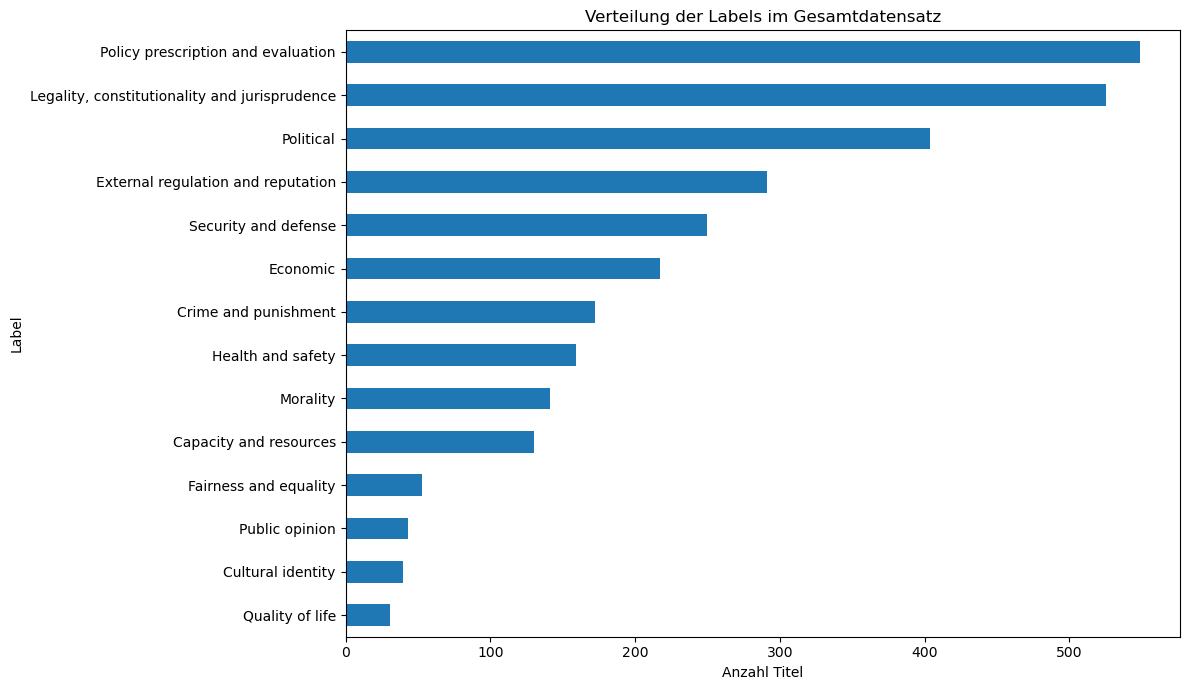

In [ ]:
gesamt_label_anzahl.sort_values().plot(kind='barh', figsize=(12, 7))
plt.title('Verteilung der Labels im Gesamtdatensatz')
plt.xlabel('Anzahl Titel')
plt.ylabel('Label')
plt.tight_layout()
plt.show()


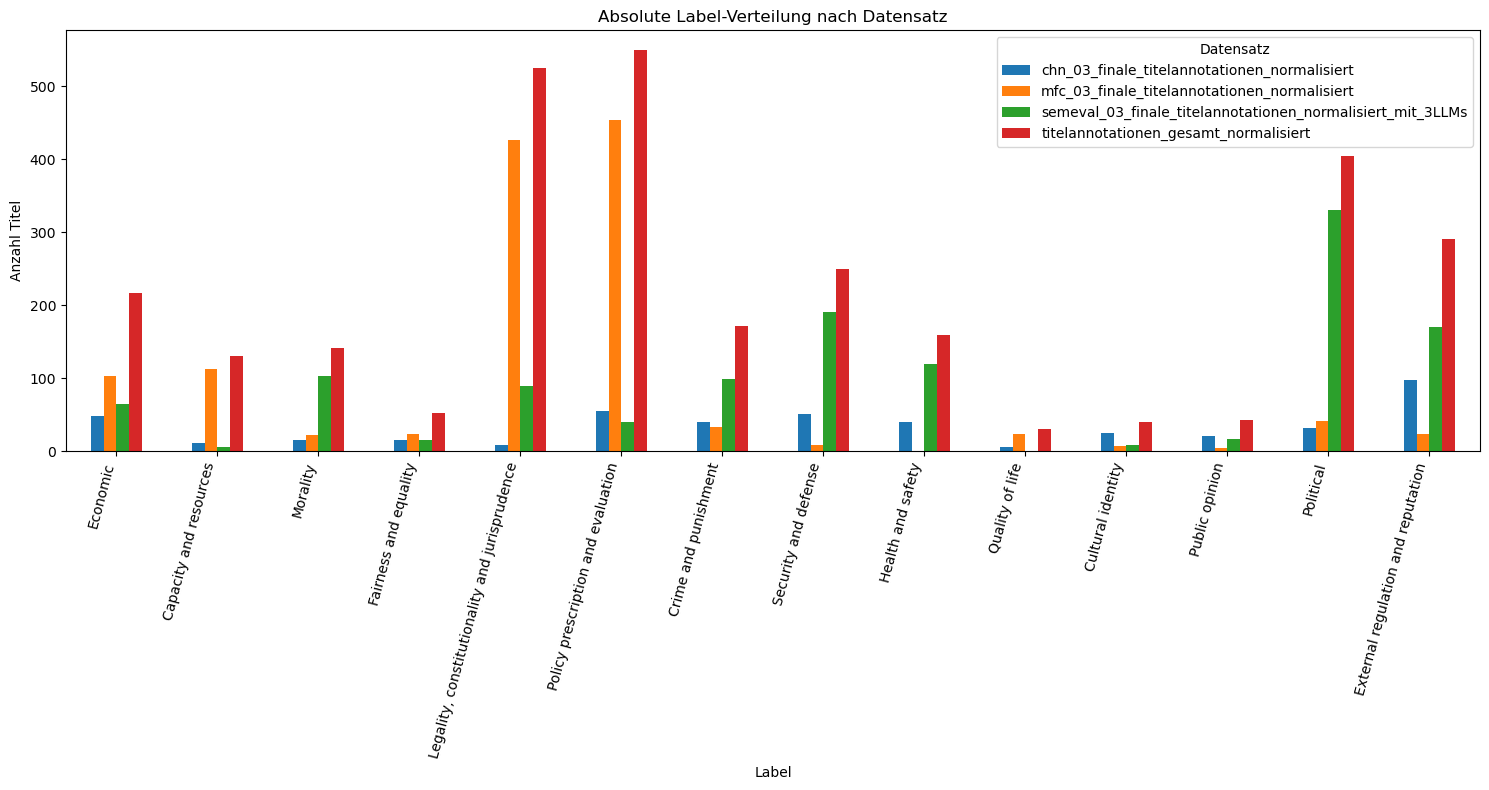

In [ ]:
label_verteilung.plot(kind='bar', figsize=(15, 8))
plt.title('Absolute Label-Verteilung nach Datensatz')
plt.xlabel('Label')
plt.ylabel('Anzahl Titel')
plt.xticks(rotation=75, ha='right')
plt.legend(title='Datensatz')
plt.tight_layout()
plt.show()


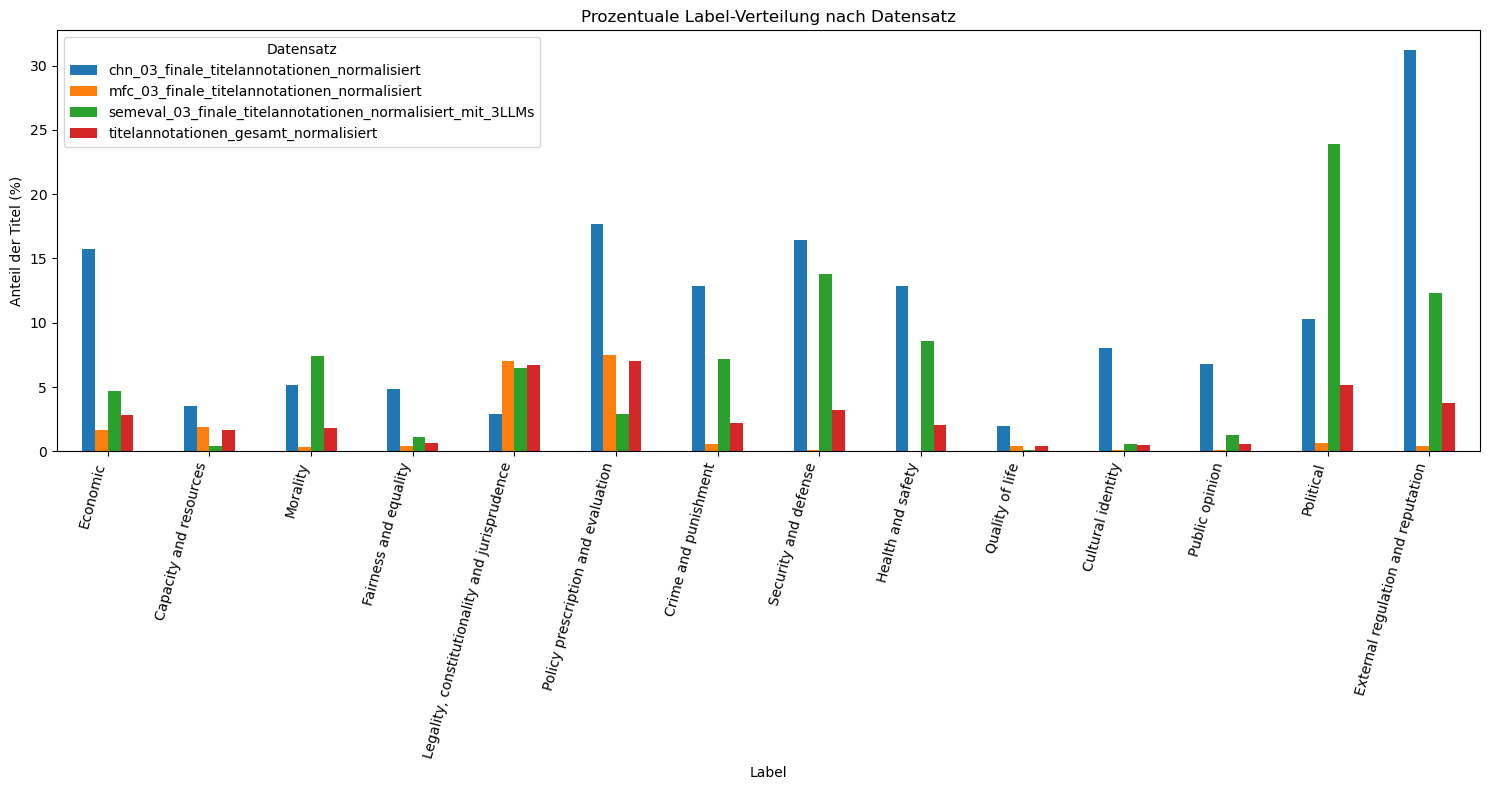

In [ ]:
label_verteilung_prozent.plot(kind='bar', figsize=(15, 8))
plt.title('Prozentuale Label-Verteilung nach Datensatz')
plt.xlabel('Label')
plt.ylabel('Anteil der Titel (%)')
plt.xticks(rotation=75, ha='right')
plt.legend(title='Datensatz')
plt.tight_layout()
plt.show()


### titles without lables vs. with lables

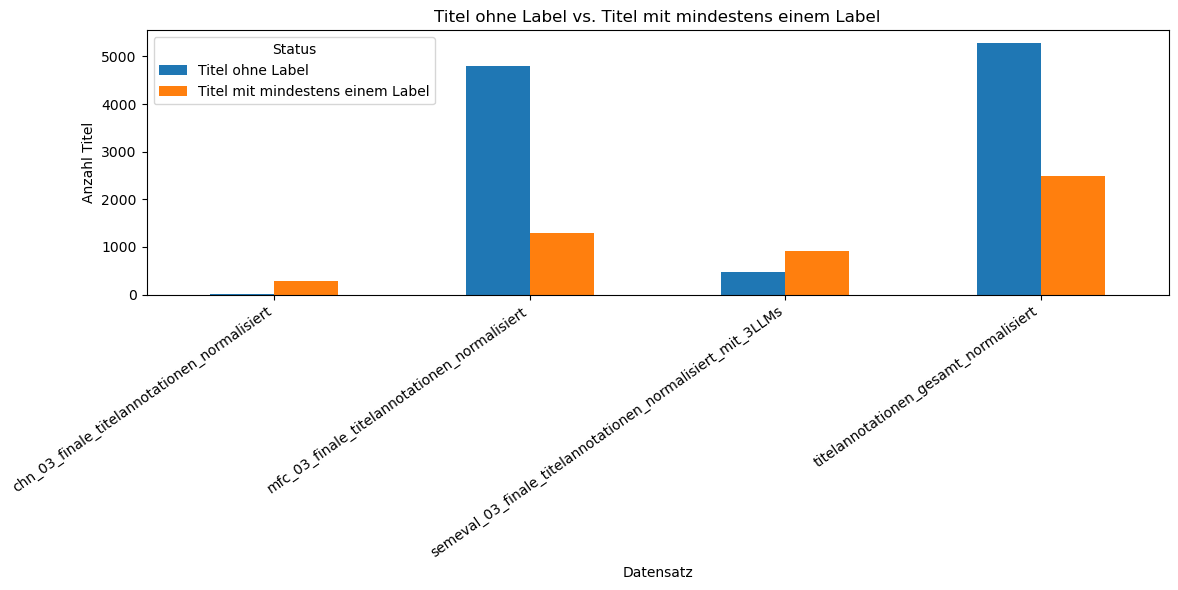

In [ ]:
plot_df = uebersicht.set_index('Datensatz')[
    ['Titel ohne Label', 'Titel mit mindestens einem Label']
]

plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Titel ohne Label vs. Titel mit mindestens einem Label')
plt.xlabel('Datensatz')
plt.ylabel('Anzahl Titel')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


### most recent lable combinations

In [ ]:
kombinationen_alle = {}

for name, df in daten_auswertung.items():
    zaehler = {}

    for _, row in df.iterrows():
        vorhanden = [label for label in label_cols if row[label] == 1]

        for kombi in combinations(sorted(vorhanden), 2):
            zaehler[kombi] = zaehler.get(kombi, 0) + 1

    s = pd.Series(zaehler, dtype='int64').sort_values(ascending=False)
    kombinationen_alle[name] = s

for name, s in kombinationen_alle.items():
    print('\n' + '=' * 90)
    print(name)
    print('=' * 90)
    if len(s):
        display(s.head(15).rename('Anzahl gemeinsamer Titel').to_frame())
    else:
        print('Keine Titel mit mindestens zwei Labels gefunden.')



chn_03_finale_titelannotationen_normalisiert


Anzahl gemeinsamer Titel
External regulation and reputation Security and defense                                      32
Economic                           Policy prescription and evaluation                        15
External regulation and reputation Policy prescription and evaluation                        12
Economic                           External regulation and reputation                        11
Policy prescription and evaluation Security and defense                                       8
Health and safety                  Policy prescription and evaluation                         8
Fairness and equality              Policy prescription and evaluation                         7
External regulation and reputation Morality                                                   6
Crime and punishment               Public opinion                                             6
                                   Security and defense                                       6
Political                          Public opinion                                             6
External regulation and reputation Political                                                  6
Political                          Security and defense                                       5
Crime and punishment               External regulation and reputation                         5
Cultural identity                  Economic                                                   5


mfc_03_finale_titelannotationen_normalisiert
Keine Titel mit mindestens zwei Labels gefunden.

semeval_03_finale_titelannotationen_normalisiert_mit_3LLMs


,,Anzahl gemeinsamer Titel
External regulation and reputation,Security and defense,51
"Legality, constitutionality and jurisprudence",Political,46
External regulation and reputation,Political,39
Political,Security and defense,25
Crime and punishment,Security and defense,20
Morality,Political,18
Policy prescription and evaluation,Political,16
Crime and punishment,"Legality, constitutionality and jurisprudence",16
Economic,External regulation and reputation,15
Crime and punishment,Political,14



titelannotationen_gesamt_normalisiert


,,Anzahl gemeinsamer Titel
External regulation and reputation,Security and defense,83
"Legality, constitutionality and jurisprudence",Political,47
External regulation and reputation,Political,45
Political,Security and defense,30
Economic,External regulation and reputation,26
Crime and punishment,Security and defense,26
External regulation and reputation,Policy prescription and evaluation,19
Policy prescription and evaluation,Political,18
Crime and punishment,"Legality, constitutionality and jurisprudence",18
Morality,Political,18


### Co-Occurrence-Matrix

In [ ]:
def cooccurrence_matrix(df, labels):
    binary = df[labels].fillna(0).astype(int)
    return binary.T.dot(binary)

co_matrix = cooccurrence_matrix(gesamt_df, label_cols)
co_matrix


,Economic,Capacity and resources,Morality,Fairness and equality,"Legality, constitutionality and jurisprudence",Policy prescription and evaluation,Crime and punishment,Security and defense,Health and safety,Quality of life,Cultural identity,Public opinion,Political,External regulation and reputation
Economic,217,2,0,2,2,18,0,8,2,3,5,2,12,26
Capacity and resources,2,130,0,0,0,3,0,0,2,0,1,0,0,0
Morality,0,0,141,1,14,2,16,8,2,0,6,1,18,8
Fairness and equality,2,0,1,53,3,7,3,0,0,1,0,2,3,4
"Legality, constitutionality and jurisprudence",2,0,14,3,525,6,18,6,2,0,0,2,47,7
Policy prescription and evaluation,18,3,2,7,6,549,3,13,10,3,2,4,18,19
Crime and punishment,0,0,16,3,18,3,172,26,5,0,0,6,16,7
Security and defense,8,0,8,0,6,13,26,250,0,0,0,1,30,83
Health and safety,2,2,2,0,2,10,5,0,159,0,0,4,4,6
Quality of life,3,0,0,1,0,3,0,0,0,31,0,0,0,0


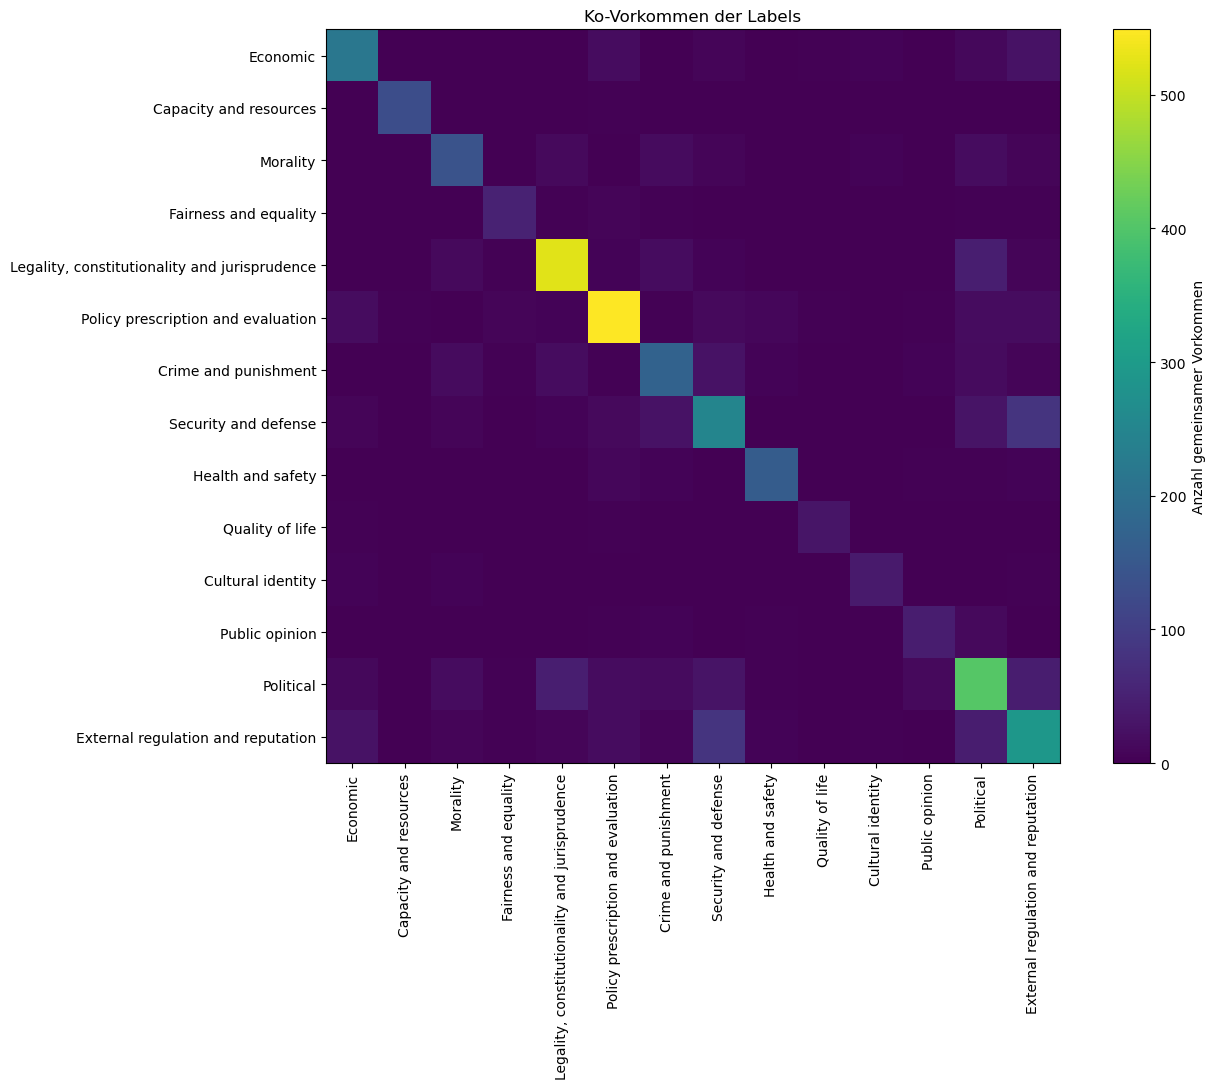

In [ ]:
plt.figure(figsize=(14, 11))
plt.imshow(co_matrix.values)
plt.xticks(range(len(label_cols)), label_cols, rotation=90)
plt.yticks(range(len(label_cols)), label_cols)
plt.colorbar(label='Anzahl gemeinsamer Vorkommen')
plt.title('Ko-Vorkommen der Labels')
plt.tight_layout()
plt.show()
